# Bibliotecas

In [1]:
# =============================
# BIBLIOTECAS
# =============================
import os
import getpass
import warnings
from pathlib import Path
import html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sqlalchemy import create_engine

warnings.filterwarnings("ignore")

# =============================
# CONFIGURAÇÕES GERAIS
# =============================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

# Configurações banco de dados

In [2]:
# =============================
# CONEXÃO COM O BANCO
# =============================
db_engine = globals().get("db_engine", None)

if not db_engine:
    host = "localhost"
    database = "MF"
    
    user = input("Digite seu usuário MySQL: ")
    password = getpass.getpass("Digite sua senha MySQL (não será exibida): ")
    
    db_engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")
    print("Configuração do Banco de Dados criada com sucesso!")
else:
    print("Configuração já existe. Usando configuração já existente!")

Digite seu usuário MySQL:  tomida
Digite sua senha MySQL (não será exibida):  ········


Configuração do Banco de Dados criada com sucesso!


# Configurações Iniciais

## Pastas para armazenar resultados

In [3]:
# =============================
# PASTAS DE SAÍDA
# =============================
BASE_DIR = Path.cwd()

RESULTADOS_DIR = BASE_DIR / "resultados"
GRAFICOS_DIR = RESULTADOS_DIR / "graficos"
TABELAS_DIR = RESULTADOS_DIR / "tabelas"
PARQUETS_DIR = RESULTADOS_DIR / "parquets"

RESULTADOS_DIR.mkdir(exist_ok=True)
GRAFICOS_DIR.mkdir(exist_ok=True)
TABELAS_DIR.mkdir(exist_ok=True)
PARQUETS_DIR.mkdir(exist_ok=True)

print("Pastas prontas:")
print(f"- {RESULTADOS_DIR}")
print(f"- {GRAFICOS_DIR}")
print(f"- {TABELAS_DIR}")
print(f"- {PARQUETS_DIR}")

Pastas prontas:
- C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados
- C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos
- C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas
- C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets


## Funções auxiliares

In [4]:
# =============================
# FUNÇÕES UTILITÁRIAS
# =============================
def salvar_grafico(fig, nome_arquivo, pasta=GRAFICOS_DIR):
    """
    Salva uma figura matplotlib em PNG com boa resolução.
    """
    caminho = pasta / f"{nome_arquivo}.png"
    fig.savefig(caminho, bbox_inches="tight", dpi=300)
    print(f"Gráfico salvo em: {caminho}")


def salvar_tabela(df, nome_arquivo, pasta=TABELAS_DIR, index=False):
    """
    Salva um dataframe em CSV.
    """
    caminho = pasta / f"{nome_arquivo}.csv"
    df.to_csv(caminho, index=index, encoding="utf-8-sig")
    print(f"Tabela salva em: {caminho}")


def salvar_parquet(df, nome_arquivo, pasta=PARQUETS_DIR, index=False):
    """
    Salva um dataframe em parquet.
    """
    caminho = pasta / f"{nome_arquivo}.parquet"
    df.to_parquet(caminho, index=index)
    print(f"Parquet salvo em: {caminho}")

# Dados Macroeconômicos

In [5]:
def consulta_bc(codigo_bcb):
    """
    Consulta uma série temporal da API do Banco Central (SGS).
    Retorna um dataframe indexado por data com a coluna 'valor'.
    """
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_bcb}/dados?formato=json"
    
    df = pd.read_json(url)
    df["data"] = pd.to_datetime(df["data"], dayfirst=True)
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df = df.dropna().set_index("data").sort_index()
    
    return df

In [6]:
# =============================
# CÓDIGOS DADOS MACROECONÔMICOS
# =============================
series_bcb = {
    "ipca": 433,
    "dolar": 3698,
    "selic": 4189,
    "ibc_br": 24364
}

lista_macro = []

for nome, codigo in series_bcb.items():
    df_temp = consulta_bc(codigo).rename(columns={"valor": nome})
    lista_macro.append(df_temp)

df_macro = pd.concat(lista_macro, axis=1).sort_index()

# Como todas as séries escolhidas já são mensais, ainda assim deixamos a padronização:
df_macro = df_macro.resample("M").last()

# Transformações das variáveis macro
df_macro["var_dolar"] = np.log(df_macro["dolar"]).diff()
df_macro["delta_selic"] = df_macro["selic"].diff()
df_macro["delta_ipca"] = df_macro["ipca"].diff()
df_macro["ibc_var"] = df_macro["ibc_br"].pct_change()

df_macro = df_macro.dropna().copy()

display(df_macro.head())

,ipca,dolar,selic,ibc_br,var_dolar,delta_selic,delta_ipca,ibc_var
data,,,,,,,,
2003-02-28,1.57,3.5908,25.68,71.72228,0.043369,0.62,-0.68,0.016813
2003-03-31,1.23,3.4469,26.32,71.37508,-0.040900,0.64,-0.34,-0.004841
2003-04-30,0.97,3.1187,26.32,70.86834,-0.100059,0.00,-0.26,-0.007100
2003-05-31,0.61,2.9557,26.31,70.15872,-0.053681,-0.01,-0.36,-0.010013
2003-06-30,-0.15,2.8832,26.09,70.29779,-0.024835,-0.22,-0.76,0.001982


In [7]:
# =============================
# SALVAR DADOS MACRO
# =============================
salvar_tabela(df_macro.reset_index(), "df_macro")
salvar_parquet(df_macro.reset_index(), "df_macro")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_macro.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_macro.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\macro_series_nivel.png


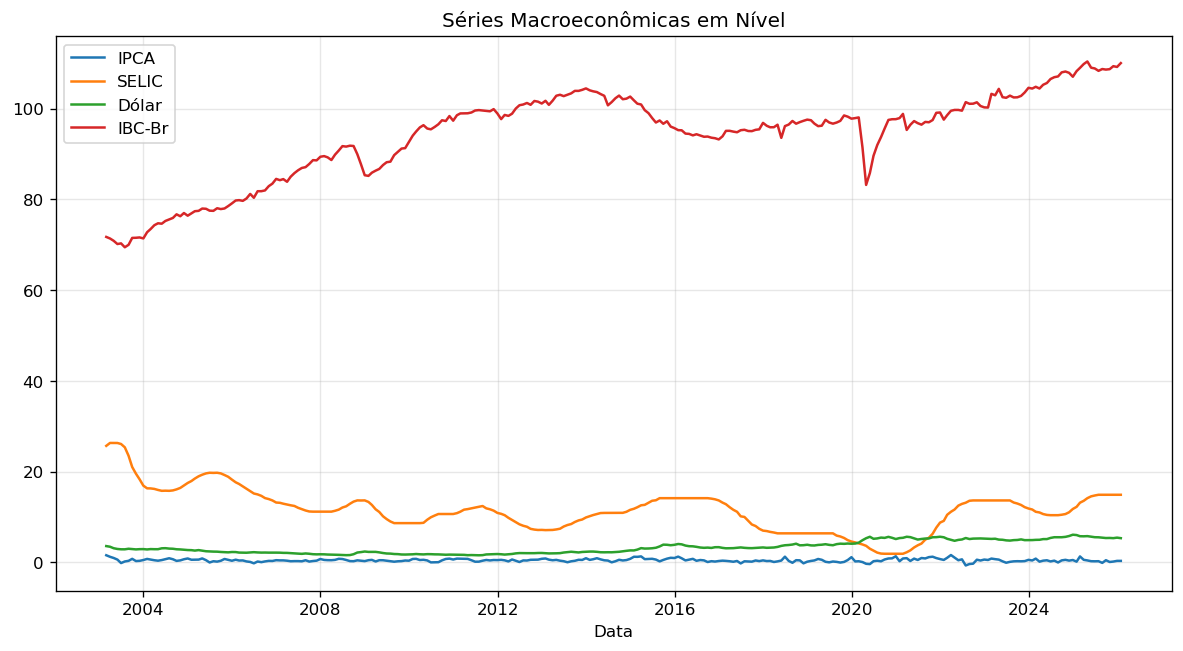

In [8]:
# Gráfico das séries em nível
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_macro.index, df_macro["ipca"], label="IPCA")
ax.plot(df_macro.index, df_macro["selic"], label="SELIC")
ax.plot(df_macro.index, df_macro["dolar"], label="Dólar")
ax.plot(df_macro.index, df_macro["ibc_br"], label="IBC-Br")
ax.set_title("Séries Macroeconômicas em Nível")
ax.set_xlabel("Data")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "macro_series_nivel")
plt.show()

Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\macro_series_base100.png


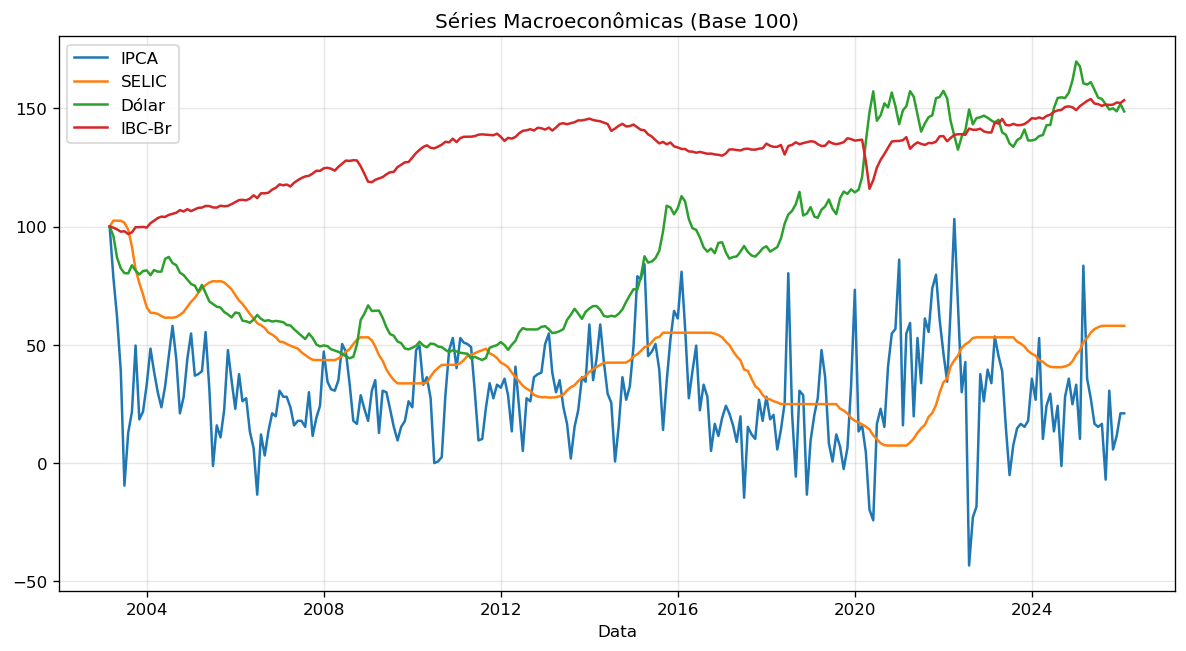

In [9]:
# =============================
# NORMALIZAÇÃO BASE 100
# =============================
df_base100 = df_macro / df_macro.iloc[0] * 100

# =============================
# GRÁFICO
# =============================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_base100.index, df_base100["ipca"], label="IPCA")
ax.plot(df_base100.index, df_base100["selic"], label="SELIC")
ax.plot(df_base100.index, df_base100["dolar"], label="Dólar")
ax.plot(df_base100.index, df_base100["ibc_br"], label="IBC-Br")

ax.set_title("Séries Macroeconômicas (Base 100)")
ax.set_xlabel("Data")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "macro_series_base100")
plt.show()

Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\macro_series_transformadas.png


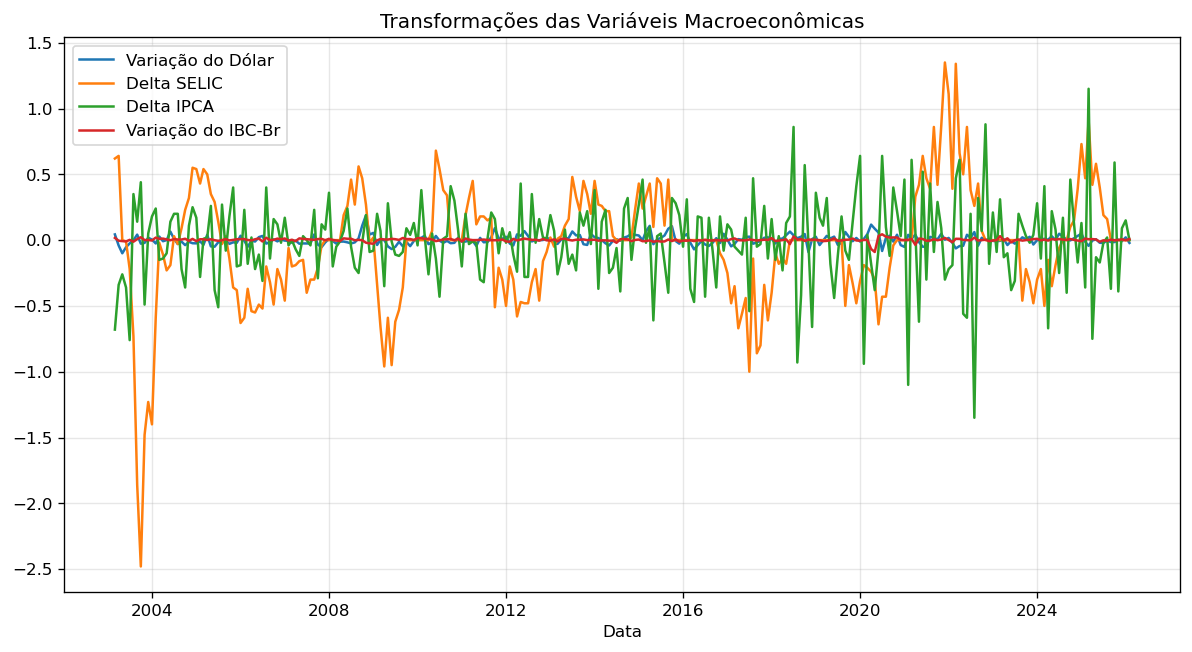

In [10]:
# Gráfico das transformações macroeconômicas
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_macro.index, df_macro["var_dolar"], label="Variação do Dólar")
ax.plot(df_macro.index, df_macro["delta_selic"], label="Delta SELIC")
ax.plot(df_macro.index, df_macro["delta_ipca"], label="Delta IPCA")
ax.plot(df_macro.index, df_macro["ibc_var"], label="Variação do IBC-Br")
ax.set_title("Transformações das Variáveis Macroeconômicas")
ax.set_xlabel("Data")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "macro_series_transformadas")
plt.show()

Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\macro_series_transformadas_base100.png


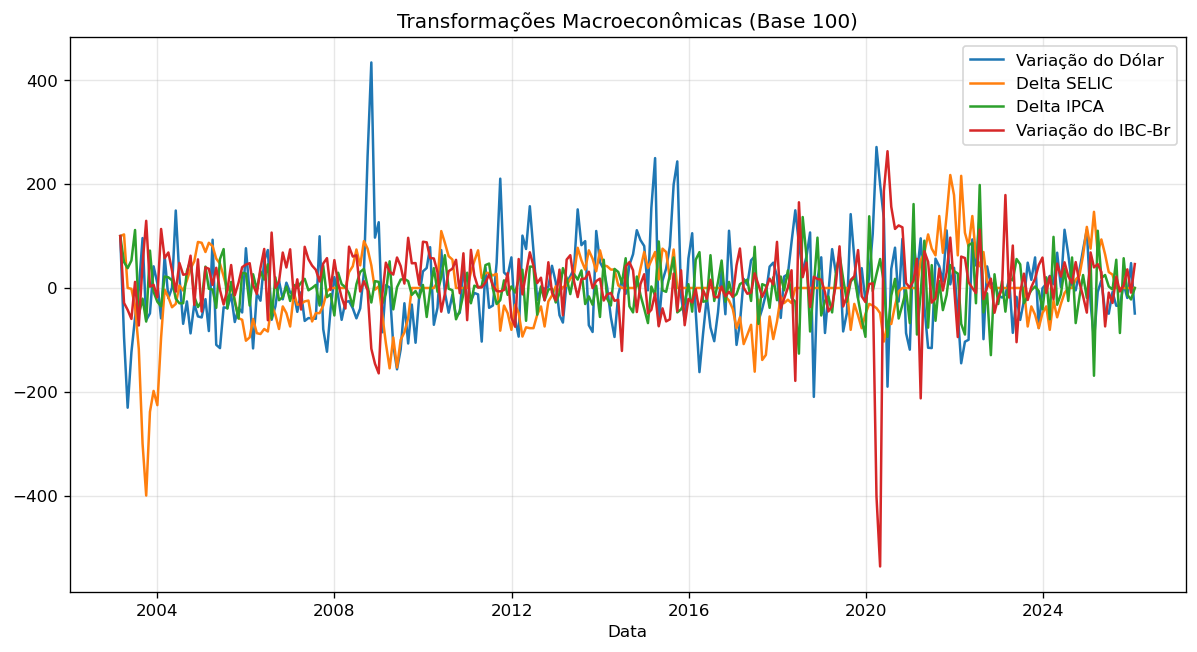

In [11]:
# =============================
# BASE 100 PARA TRANSFORMAÇÕES
# =============================
cols_transf = ["var_dolar", "delta_selic", "delta_ipca", "ibc_var"]

df_base100_transf = df_macro[cols_transf] / df_macro[cols_transf].iloc[0] * 100

# =============================
# GRÁFICO
# =============================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_base100_transf.index, df_base100_transf["var_dolar"], label="Variação do Dólar")
ax.plot(df_base100_transf.index, df_base100_transf["delta_selic"], label="Delta SELIC")
ax.plot(df_base100_transf.index, df_base100_transf["delta_ipca"], label="Delta IPCA")
ax.plot(df_base100_transf.index, df_base100_transf["ibc_var"], label="Variação do IBC-Br")

ax.set_title("Transformações Macroeconômicas (Base 100)")
ax.set_xlabel("Data")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "macro_series_transformadas_base100")
plt.show()

# Dados Índice IBOVESPA

In [12]:
# =============================
# IBOVESPA - YAHOO FINANCE
# =============================
df_ibov = yf.download("^BVSP", start="2003-01-01", auto_adjust=False, progress=False)

# Ajuste caso o retorno venha com MultiIndex
if isinstance(df_ibov.columns, pd.MultiIndex):
    df_ibov.columns = df_ibov.columns.get_level_values(0)

df_ibov = df_ibov.reset_index()

# Padroniza nomes
df_ibov = df_ibov.rename(columns={
    "Date": "data",
    "Close": "close_ibov",
    "Adj Close": "close_adj_ibov",
    "Volume": "volume_ibov"
})

# Remove NaN e valores zero
coluna_preco_ibov = "close_adj_ibov" if "close_adj_ibov" in df_ibov.columns else "close_ibov"

df_ibov = df_ibov.dropna(subset=["data", coluna_preco_ibov]).copy()
df_ibov = df_ibov[df_ibov[coluna_preco_ibov] != 0].copy()

# Frequência mensal: último fechamento do mês
df_ibov["ano_mes"] = df_ibov["data"].dt.to_period("M")

df_ibov_mensal = (
    df_ibov.groupby("ano_mes", as_index=False)
    .agg(
        data=("data", "max"),
        ibov=("close_adj_ibov", "last")
    )
)

# Retorno log do IBOV
df_ibov_mensal["ret_ibov"] = np.log(df_ibov_mensal["ibov"]).diff()
df_ibov_mensal = df_ibov_mensal.dropna().copy()

display(df_ibov_mensal.head())

,ano_mes,data,ibov,ret_ibov
1,2003-02,2003-02-28,10281.0,-0.062220
2,2003-03,2003-03-31,11274.0,0.092202
3,2003-04,2003-04-30,12557.0,0.107779
4,2003-05,2003-05-30,13422.0,0.066617
5,2003-06,2003-06-30,12973.0,-0.034025


In [13]:
# =============================
# SALVAR DADOS IBOV
# =============================
salvar_tabela(df_ibov_mensal, "df_ibov_mensal")
salvar_parquet(df_ibov_mensal, "df_ibov_mensal")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_ibov_mensal.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_ibov_mensal.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\ibov_mensal.png


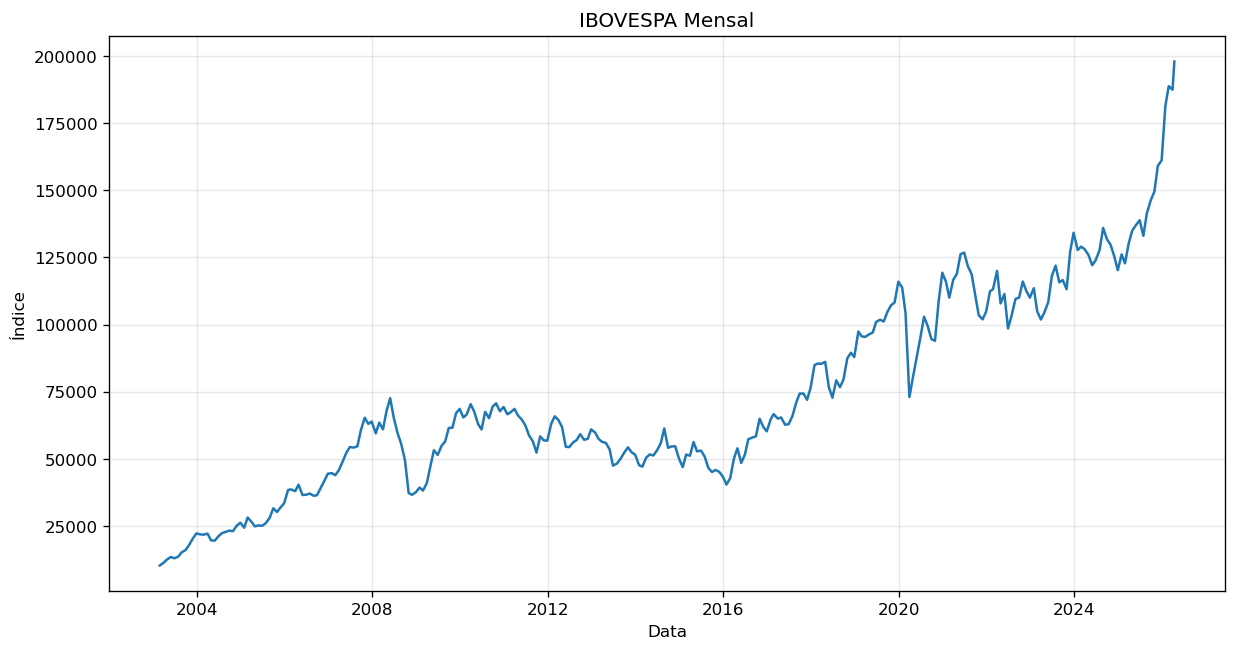

In [14]:
# Gráfico do IBOV mensal
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_ibov_mensal["data"], df_ibov_mensal["ibov"])
ax.set_title("IBOVESPA Mensal")
ax.set_xlabel("Data")
ax.set_ylabel("Índice")
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "ibov_mensal")
plt.show()

Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\ibov_retorno_mensal.png


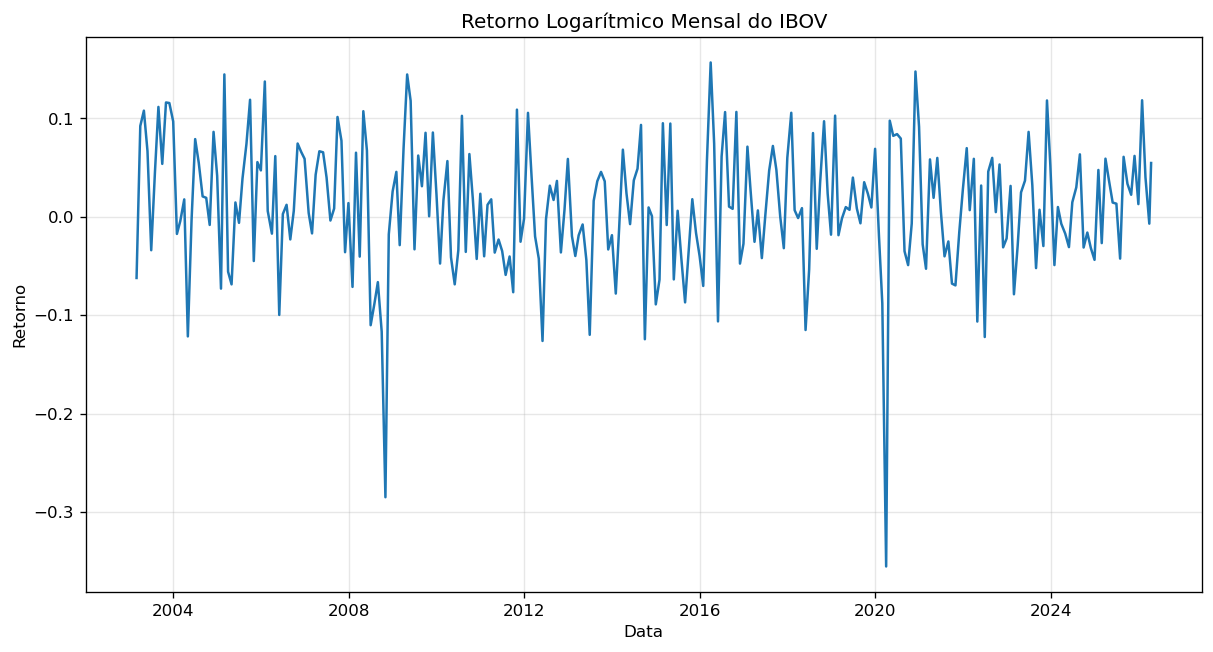

In [15]:
# Gráfico do retorno do IBOV
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_ibov_mensal["data"], df_ibov_mensal["ret_ibov"])
ax.set_title("Retorno Logarítmico Mensal do IBOV")
ax.set_xlabel("Data")
ax.set_ylabel("Retorno")
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "ibov_retorno_mensal")
plt.show()

# Dados Ações

## Selecionar tickers mais líquidos por empresa

In [16]:
# =============================
# TICKER MAIS LÍQUIDO POR EMPRESA
# =============================
query_tickers = """
WITH volume_por_ticker AS (
    SELECT 
        ticker,
        SUM(volume_fin) AS volume_total
    FROM cot_hist_consolidado
    GROUP BY ticker
),

ranking AS (
    SELECT 
        ticker,
        volume_total,
        LEFT(ticker, 4) AS empresa_base,
        ROW_NUMBER() OVER (
            PARTITION BY LEFT(ticker, 4)
            ORDER BY volume_total DESC
        ) AS rn
    FROM volume_por_ticker
)

SELECT 
    ticker,
    empresa_base,
    volume_total
FROM ranking
WHERE rn = 1
ORDER BY empresa_base
"""

df_tickers = pd.read_sql(query_tickers, db_engine)

display(df_tickers.head())
print(f"Quantidade de tickers selecionados: {len(df_tickers)}")

,ticker,empresa_base,volume_total
0,AALR3,AALR,1.213404e+10
1,ABCB4,ABCB,3.209937e+10
2,ABEV3,ABEV,9.899160e+11
3,ABYA3,ABYA,1.878905e+08
4,ADHM3,ADHM,1.164137e+08


Quantidade de tickers selecionados: 493


In [17]:
# =============================
# SALVAR TICKERS SELECIONADOS
# =============================
salvar_tabela(df_tickers, "df_tickers_mais_liquidos")
salvar_parquet(df_tickers, "df_tickers_mais_liquidos")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_tickers_mais_liquidos.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_tickers_mais_liquidos.parquet


## Dados das ações apenas para os tickers selecionados

In [18]:
# =============================
# DADOS DE AÇÕES + CLASSIFICAÇÃO
# =============================
lista_tickers = "', '".join(df_tickers["ticker"].tolist())

query_acoes = f"""
SELECT 
    c.data,
    c.ticker,
    c.close,
    c.close_adj,
    c.volume_qtd,
    c.volume_fin,
    d.setor,
    d.subsetor,
    d.segmento
FROM cot_hist_consolidado c
LEFT JOIN dados_info_empresa d
    ON c.ticker = d.ticker
WHERE c.ticker IN ('{lista_tickers}')
ORDER BY c.ticker, c.data
"""

df_acoes = pd.read_sql(query_acoes, db_engine)

df_acoes["data"] = pd.to_datetime(df_acoes["data"])
df_acoes = df_acoes.sort_values(["ticker", "data"]).copy()

display(df_acoes.head())

,data,ticker,close,close_adj,volume_qtd,volume_fin,setor,subsetor,segmento
0,2016-10-28,AALR3,19.20,18.8304,6342600,122334647.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
1,2016-10-31,AALR3,18.06,17.7157,2523300,45857231.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
2,2016-11-01,AALR3,17.90,17.5579,996200,17676981.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
3,2016-11-03,AALR3,17.99,17.6466,621000,11132994.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
4,2016-11-04,AALR3,17.75,17.4099,389800,6955112.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"


In [19]:
# =============================
# ESCOLHA DA COLUNA DE PREÇO
# =============================
# Aqui priorizamos close_adj, mas mantemos fallback para close caso haja ausência.
df_acoes["preco_base"] = np.where(
    df_acoes["close_adj"].notna() & (df_acoes["close_adj"] != 0),
    df_acoes["close_adj"],
    df_acoes["close"]
)

# Remove linhas sem preço válido
df_acoes = df_acoes.dropna(subset=["preco_base"]).copy()
df_acoes = df_acoes[df_acoes["preco_base"] != 0].copy()

display(df_acoes.head())

,data,ticker,close,close_adj,volume_qtd,volume_fin,setor,subsetor,segmento,preco_base
0,2016-10-28,AALR3,19.20,18.8304,6342600,122334647.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",18.8304
1,2016-10-31,AALR3,18.06,17.7157,2523300,45857231.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",17.7157
2,2016-11-01,AALR3,17.90,17.5579,996200,17676981.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",17.5579
3,2016-11-03,AALR3,17.99,17.6466,621000,11132994.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",17.6466
4,2016-11-04,AALR3,17.75,17.4099,389800,6955112.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",17.4099


In [20]:
# =============================
# SALVAR BASE DIÁRIA DE AÇÕES
# =============================
salvar_tabela(df_acoes, "df_acoes_diario")
salvar_parquet(df_acoes, "df_acoes_diario")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_acoes_diario.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_acoes_diario.parquet


### Consolidação Mensal das Ações

In [21]:
# =============================
# CONSOLIDAÇÃO MENSAL DAS AÇÕES
# =============================
df_acoes["ano_mes"] = df_acoes["data"].dt.to_period("M")

df_mensal = (
    df_acoes.groupby(["ticker", "ano_mes"], as_index=False)
    .agg(
        data=("data", "max"),
        preco=("preco_base", "last"),
        volume_qtd=("volume_qtd", "sum"),
        volume_fin=("volume_fin", "sum"),
        setor=("setor", "first"),
        subsetor=("subsetor", "first"),
        segmento=("segmento", "first")
    )
).copy()

df_mensal = df_mensal.sort_values(["ticker", "data"]).copy()

display(df_mensal.head())

,ticker,ano_mes,data,preco,volume_qtd,volume_fin,setor,subsetor,segmento
0,AALR3,2016-10,2016-10-31,17.7157,8865900,168191878.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
1,AALR3,2016-11,2016-11-30,15.5457,9650500,159956126.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
2,AALR3,2016-12,2016-12-29,14.3718,7245600,105583723.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
3,AALR3,2017-01,2017-01-31,13.6715,3920900,57625050.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"
4,AALR3,2017-02,2017-02-24,12.4977,4148400,54993951.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos"


In [22]:
# =============================
# CÁLCULO DOS RETORNOS DAS AÇÕES
# =============================
df_mensal["ret_acao"] = (
    df_mensal.groupby("ticker")["preco"]
    .transform(lambda x: np.log(x).diff())
)

df_mensal = df_mensal.dropna(subset=["ret_acao"]).copy()

display(df_mensal.head())

,ticker,ano_mes,data,preco,volume_qtd,volume_fin,setor,subsetor,segmento,ret_acao
1,AALR3,2016-11,2016-11-30,15.5457,9650500,159956126.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.130667
2,AALR3,2016-12,2016-12-29,14.3718,7245600,105583723.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.078516
3,AALR3,2017-01,2017-01-31,13.6715,3920900,57625050.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.049955
4,AALR3,2017-02,2017-02-24,12.4977,4148400,54993951.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.089769
5,AALR3,2017-03,2017-03-31,15.3286,6010500,80695487.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",0.204176


In [23]:
# =============================
# SALVAR BASE MENSAL DE AÇÕES
# =============================
salvar_tabela(df_mensal, "df_mensal_acoes")
salvar_parquet(df_mensal, "df_mensal_acoes")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_mensal_acoes.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_mensal_acoes.parquet


# Dados por setor, subsetor e segmento

In [24]:
# =============================
# RETORNO POR SETOR
# =============================
df_setor = (
    df_mensal.groupby(["ano_mes", "setor"], as_index=False)
    .agg(
        ret_setor=("ret_acao", "mean"),
        n_empresas=("ticker", "nunique")
    )
)

df_setor["data"] = df_setor["ano_mes"].dt.to_timestamp(how="end").dt.normalize()

# =============================
# RETORNO POR SUBSETOR
# =============================
df_subsetor = (
    df_mensal.groupby(["ano_mes", "subsetor"], as_index=False)
    .agg(
        ret_subsetor=("ret_acao", "mean"),
        n_empresas=("ticker", "nunique")
    )
)

df_subsetor["data"] = df_subsetor["ano_mes"].dt.to_timestamp(how="end").dt.normalize()

# =============================
# RETORNO POR SEGMENTO
# =============================
df_segmento = (
    df_mensal.groupby(["ano_mes", "segmento"], as_index=False)
    .agg(
        ret_segmento=("ret_acao", "mean"),
        n_empresas=("ticker", "nunique")
    )
)

df_segmento["data"] = df_segmento["ano_mes"].dt.to_timestamp(how="end").dt.normalize()

display(df_setor.head())
display(df_subsetor.head())
display(df_segmento.head())

,ano_mes,setor,ret_setor,n_empresas,data
0,2010-02,Bens Industriais,0.059726,32,2010-02-28
1,2010-02,Comunicações,0.269681,1,2010-02-28
2,2010-02,Consumo Cíclico,0.045795,60,2010-02-28
3,2010-02,Consumo não Cíclico,-0.018817,13,2010-02-28
4,2010-02,Financeiro,0.017887,44,2010-02-28


,ano_mes,subsetor,ret_subsetor,n_empresas,data
0,2010-02,Agropecuária,-0.030032,3,2010-02-28
1,2010-02,Alimentos Processados,-0.019596,8,2010-02-28
2,2010-02,Automóveis e Motocicletas,-0.004789,2,2010-02-28
3,2010-02,Computadores e Equipamentos,-0.027649,3,2010-02-28
4,2010-02,Comércio Varejista,-0.015762,7,2010-02-28


,ano_mes,segmento,ret_segmento,n_empresas,data
0,2010-02,Acessórios,0.000000,1,2010-02-28
1,2010-02,Agricultura,-0.030032,3,2010-02-28
2,2010-02,Alimentos Diversos,0.001630,2,2010-02-28
3,2010-02,Aluguel de carros,-0.001912,1,2010-02-28
4,2010-02,Armas e Munições,-0.023657,1,2010-02-28


In [25]:
# =============================
# SALVAR BASES SETORIAIS
# =============================
salvar_tabela(df_setor, "df_setor")
salvar_parquet(df_setor, "df_setor")

salvar_tabela(df_subsetor, "df_subsetor")
salvar_parquet(df_subsetor, "df_subsetor")

salvar_tabela(df_segmento, "df_segmento")
salvar_parquet(df_segmento, "df_segmento")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_setor.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_setor.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_subsetor.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_subsetor.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_segmento.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_segmento.parquet


# Consolidando com dados Macro

In [26]:
# =============================
# DATASET FINAL - IBOV + MACRO
# =============================
df_final_ibov = df_ibov_mensal.merge(
    df_macro,
    left_on="data",
    right_index=True,
    how="inner"
).sort_values("data").copy()

# =============================
# DATASET FINAL - AÇÕES + MACRO
# =============================
df_final_acoes = df_mensal.merge(
    df_macro,
    left_on="data",
    right_index=True,
    how="inner"
).sort_values(["ticker", "data"]).copy()

# =============================
# DATASET FINAL - SETOR + MACRO
# =============================
df_final_setor = df_setor.merge(
    df_macro,
    left_on="data",
    right_index=True,
    how="inner"
).sort_values(["setor", "data"]).copy()

# =============================
# DATASET FINAL - SUBSETOR + MACRO
# =============================
df_final_subsetor = df_subsetor.merge(
    df_macro,
    left_on="data",
    right_index=True,
    how="inner"
).sort_values(["subsetor", "data"]).copy()

# =============================
# DATASET FINAL - SEGMENTO + MACRO
# =============================
df_final_segmento = df_segmento.merge(
    df_macro,
    left_on="data",
    right_index=True,
    how="inner"
).sort_values(["segmento", "data"]).copy()

display(df_final_ibov.head())
display(df_final_acoes.head())
display(df_final_setor.head())

,ano_mes,data,ibov,ret_ibov,ipca,dolar,selic,ibc_br,var_dolar,delta_selic,delta_ipca,ibc_var
1,2003-02,2003-02-28,10281.0,-0.062220,1.57,3.5908,25.68,71.72228,0.043369,0.62,-0.68,0.016813
2,2003-03,2003-03-31,11274.0,0.092202,1.23,3.4469,26.32,71.37508,-0.040900,0.64,-0.34,-0.004841
3,2003-04,2003-04-30,12557.0,0.107779,0.97,3.1187,26.32,70.86834,-0.100059,0.00,-0.26,-0.007100
5,2003-06,2003-06-30,12973.0,-0.034025,-0.15,2.8832,26.09,70.29779,-0.024835,-0.22,-0.76,0.001982
6,2003-07,2003-07-31,13572.0,0.045139,0.20,2.8798,25.36,69.44384,-0.001180,-0.73,0.35,-0.012148


,ticker,ano_mes,data,preco,volume_qtd,volume_fin,setor,subsetor,segmento,ret_acao,ipca,dolar,selic,ibc_br,var_dolar,delta_selic,delta_ipca,ibc_var
1,AALR3,2016-11,2016-11-30,15.5457,9650500,159956126.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.130667,0.18,3.3420,13.90,93.47435,0.047866,-0.15,-0.08,-0.001236
3,AALR3,2017-01,2017-01-31,13.6715,3920900,57625050.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.049955,0.38,3.1966,13.17,93.89639,-0.047559,-0.48,0.08,0.007368
5,AALR3,2017-03,2017-03-31,15.3286,6010500,80695487.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",0.204176,0.25,3.1279,12.15,95.10616,0.007606,-0.67,-0.08,0.000090
7,AALR3,2017-05,2017-05-31,17.3902,8031200,141579767.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.047085,0.31,3.2095,11.15,94.78815,0.023103,-0.44,0.17,-0.001483
8,AALR3,2017-06,2017-06-30,17.2027,8063100,143518466.0,Saúde,"Serv.Méd.Hospit.,Análises e Diagnósticos","Serv.Méd.Hospit.,Análises e Diagnósticos",-0.010840,-0.23,3.2954,10.15,95.23790,0.026412,-1.00,-0.54,0.004745


,ano_mes,setor,ret_setor,n_empresas,data,ipca,dolar,selic,ibc_br,var_dolar,delta_selic,delta_ipca,ibc_var
0,2010-02,Bens Industriais,0.059726,32,2010-02-28,0.78,1.8416,8.65,94.94668,0.034134,0.00,0.03,0.009745
11,2010-03,Bens Industriais,-0.027003,32,2010-03-31,0.52,1.7858,8.65,95.85478,-0.030768,0.00,-0.26,0.009564
22,2010-04,Bens Industriais,-0.026864,33,2010-04-30,0.57,1.7566,8.72,96.34601,-0.016486,0.07,0.05,0.005125
33,2010-05,Bens Industriais,-0.069225,34,2010-05-31,0.43,1.8132,9.40,95.60750,0.031713,0.68,-0.14,-0.007665
44,2010-06,Bens Industriais,0.022600,35,2010-06-30,0.00,1.8065,9.94,95.43252,-0.003702,0.54,-0.43,-0.001830


In [27]:
# =============================
# SALVAR DATASETS FINAIS
# =============================
salvar_tabela(df_final_ibov, "df_final_ibov_macro")
salvar_parquet(df_final_ibov, "df_final_ibov_macro")

salvar_tabela(df_final_acoes, "df_final_acoes_macro")
salvar_parquet(df_final_acoes, "df_final_acoes_macro")

salvar_tabela(df_final_setor, "df_final_setor_macro")
salvar_parquet(df_final_setor, "df_final_setor_macro")

salvar_tabela(df_final_subsetor, "df_final_subsetor_macro")
salvar_parquet(df_final_subsetor, "df_final_subsetor_macro")

salvar_tabela(df_final_segmento, "df_final_segmento_macro")
salvar_parquet(df_final_segmento, "df_final_segmento_macro")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_final_ibov_macro.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_final_ibov_macro.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_final_acoes_macro.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_final_acoes_macro.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\df_final_setor_macro.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\df_final_setor_macro.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\d

## Tabela Resumo para Conferência

In [28]:
# Resumo das dimensões das bases
df_resumo_bases = pd.DataFrame({
    "base": [
        "df_macro",
        "df_ibov_mensal",
        "df_tickers",
        "df_acoes",
        "df_mensal",
        "df_setor",
        "df_subsetor",
        "df_segmento",
        "df_final_ibov",
        "df_final_acoes",
        "df_final_setor",
        "df_final_subsetor",
        "df_final_segmento"
    ],
    "linhas": [
        len(df_macro),
        len(df_ibov_mensal),
        len(df_tickers),
        len(df_acoes),
        len(df_mensal),
        len(df_setor),
        len(df_subsetor),
        len(df_segmento),
        len(df_final_ibov),
        len(df_final_acoes),
        len(df_final_setor),
        len(df_final_subsetor),
        len(df_final_segmento)
    ],
    "colunas": [
        df_macro.shape[1],
        df_ibov_mensal.shape[1],
        df_tickers.shape[1],
        df_acoes.shape[1],
        df_mensal.shape[1],
        df_setor.shape[1],
        df_subsetor.shape[1],
        df_segmento.shape[1],
        df_final_ibov.shape[1],
        df_final_acoes.shape[1],
        df_final_setor.shape[1],
        df_final_subsetor.shape[1],
        df_final_segmento.shape[1]
    ]
})

display(df_resumo_bases)

,base,linhas,colunas
0,df_macro,276,8
1,df_ibov_mensal,279,4
2,df_tickers,493,3
3,df_acoes,1010921,11
4,df_mensal,55976,10
5,df_setor,2101,5
6,df_subsetor,7568,5
7,df_segmento,14299,5
8,df_final_ibov,177,12
9,df_final_acoes,31596,18


In [29]:
# Salvar
salvar_tabela(df_resumo_bases, "resumo_bases")
salvar_parquet(df_resumo_bases, "resumo_bases")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\resumo_bases.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\resumo_bases.parquet


# Funções auxiliares da análise

In [30]:
def calcular_correlacoes_lag(df, y_col, x_cols, max_lag=6):
    """
    Calcula a correlação entre a variável dependente e as variáveis explicativas
    em diferentes defasagens.
    """
    resultados = []

    for var in x_cols:
        for lag in range(0, max_lag + 1):
            corr = df[y_col].corr(df[var].shift(lag))
            resultados.append({
                "variavel": var,
                "lag": lag,
                "correlacao": corr
            })

    return pd.DataFrame(resultados)


def escolher_melhor_lag(df_lags):
    """
    Escolhe o lag com maior correlação absoluta para cada variável.
    """
    temp = df_lags.copy()
    temp["abs_corr"] = temp["correlacao"].abs()

    df_best = (
        temp.sort_values(["variavel", "abs_corr"], ascending=[True, False])
            .groupby("variavel", as_index=False)
            .first()[["variavel", "lag", "correlacao"]]
            .rename(columns={"lag": "melhor_lag"})
    )

    return df_best


def aplicar_lags_escolhidos(df, df_best_lags):
    """
    Cria as colunas com os lags escolhidos.
    """
    df = df.copy()

    for _, row in df_best_lags.iterrows():
        var = row["variavel"]
        lag = int(row["melhor_lag"])
        df[f"{var}_lag"] = df[var].shift(lag)

    return df


def rodar_regressao(df, y_col, x_cols):
    """
    Roda regressão OLS simples com as colunas especificadas.
    """
    temp = df[[y_col] + x_cols].dropna().copy()

    X = temp[x_cols]
    X = sm.add_constant(X)
    y = temp[y_col]

    model = sm.OLS(y, X).fit()

    df_coef = pd.DataFrame({
        "variavel": model.params.index,
        "coef": model.params.values,
        "pvalor": model.pvalues.values
    })

    return model, df_coef, temp

In [31]:
# Funções auxiliares para clusterização
def preparar_base_cluster(df, id_col, beta_cols):
    """
    Prepara a base para clusterização:
    - seleciona colunas relevantes
    - remove missing
    """
    temp = df[[id_col] + beta_cols].dropna().copy()
    return temp


def aplicar_kmeans(df, id_col, beta_cols, n_clusters=4):
    """
    Aplica KMeans sobre os betas padronizados.
    Retorna:
    - dataframe original com cluster
    - centróides na escala padronizada
    - centróides na escala original
    """
    temp = preparar_base_cluster(df, id_col, beta_cols)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(temp[beta_cols])

    modelo = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    temp["cluster"] = modelo.fit_predict(X_scaled)

    centroides_scaled = pd.DataFrame(
        modelo.cluster_centers_,
        columns=beta_cols
    )
    centroides_scaled["cluster"] = range(n_clusters)

    centroides_orig = pd.DataFrame(
        scaler.inverse_transform(modelo.cluster_centers_),
        columns=beta_cols
    )
    centroides_orig["cluster"] = range(n_clusters)

    return temp, centroides_scaled, centroides_orig


def classificar_sensibilidade(df, id_col, beta_cols):
    """
    Cria rankings individuais por variável macro.
    """
    rankings = {}

    for col in beta_cols:
        rankings[f"top_positivo_{col}"] = df[[id_col, col]].dropna().sort_values(col, ascending=False)
        rankings[f"top_negativo_{col}"] = df[[id_col, col]].dropna().sort_values(col, ascending=True)

    return rankings

# IBOV X MACRO

## Correlação Simples

In [32]:
# IBOV - Correlação simples
macro_cols = ["delta_selic", "delta_ipca", "var_dolar", "ibc_var"]

corr_ibov = df_final_ibov[["ret_ibov"] + macro_cols].corr()

display(corr_ibov)

salvar_tabela(corr_ibov.reset_index(), "ibov_correlacao_simples")
salvar_parquet(corr_ibov.reset_index(), "ibov_correlacao_simples")

,ret_ibov,delta_selic,delta_ipca,var_dolar,ibc_var
ret_ibov,1.000000,-0.124490,-0.003770,-0.581120,0.142612
delta_selic,-0.124490,1.000000,-0.079661,0.024743,-0.050183
delta_ipca,-0.003770,-0.079661,1.000000,-0.068573,0.164491
var_dolar,-0.581120,0.024743,-0.068573,1.000000,-0.330949
ibc_var,0.142612,-0.050183,0.164491,-0.330949,1.000000


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_correlacao_simples.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_correlacao_simples.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\ibov_correlacao_simples.png


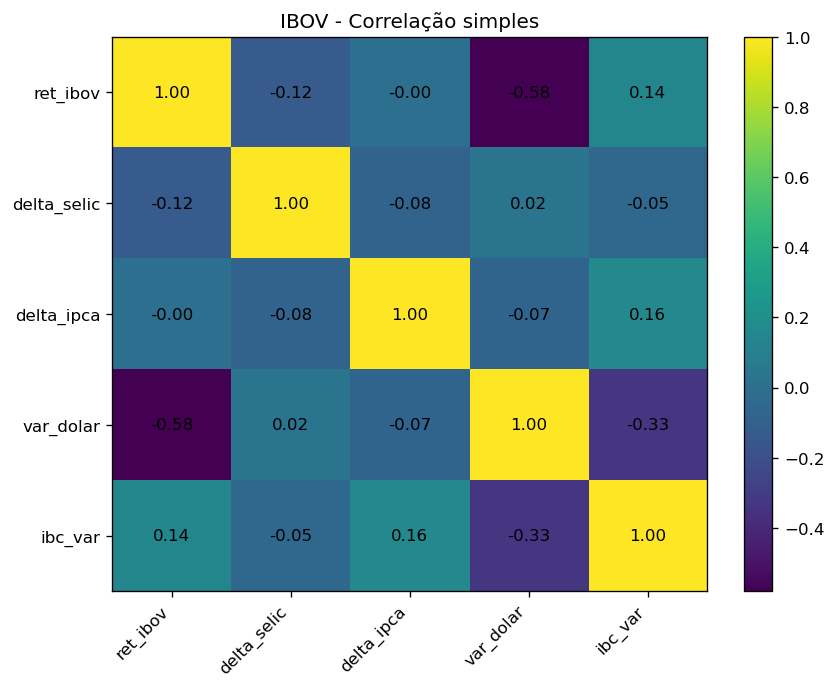

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_ibov, aspect="auto")

ax.set_xticks(range(len(corr_ibov.columns)))
ax.set_xticklabels(corr_ibov.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_ibov.index)))
ax.set_yticklabels(corr_ibov.index)

for i in range(corr_ibov.shape[0]):
    for j in range(corr_ibov.shape[1]):
        ax.text(j, i, f"{corr_ibov.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("IBOV - Correlação simples")
fig.colorbar(im, ax=ax)

salvar_grafico(fig, "ibov_correlacao_simples")
plt.show()

## Lags (Defasagem)

In [34]:
# IBOV - Correlação com lags
df_lags_ibov = calcular_correlacoes_lag(
    df=df_final_ibov.sort_values("data"),
    y_col="ret_ibov",
    x_cols=macro_cols,
    max_lag=6
)

display(df_lags_ibov.head())

salvar_tabela(df_lags_ibov, "ibov_lags")
salvar_parquet(df_lags_ibov, "ibov_lags")

,variavel,lag,correlacao
0,delta_selic,0,-0.124490
1,delta_selic,1,-0.137586
2,delta_selic,2,-0.001693
3,delta_selic,3,-0.011566
4,delta_selic,4,-0.054570


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_lags.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\ibov_lags.png


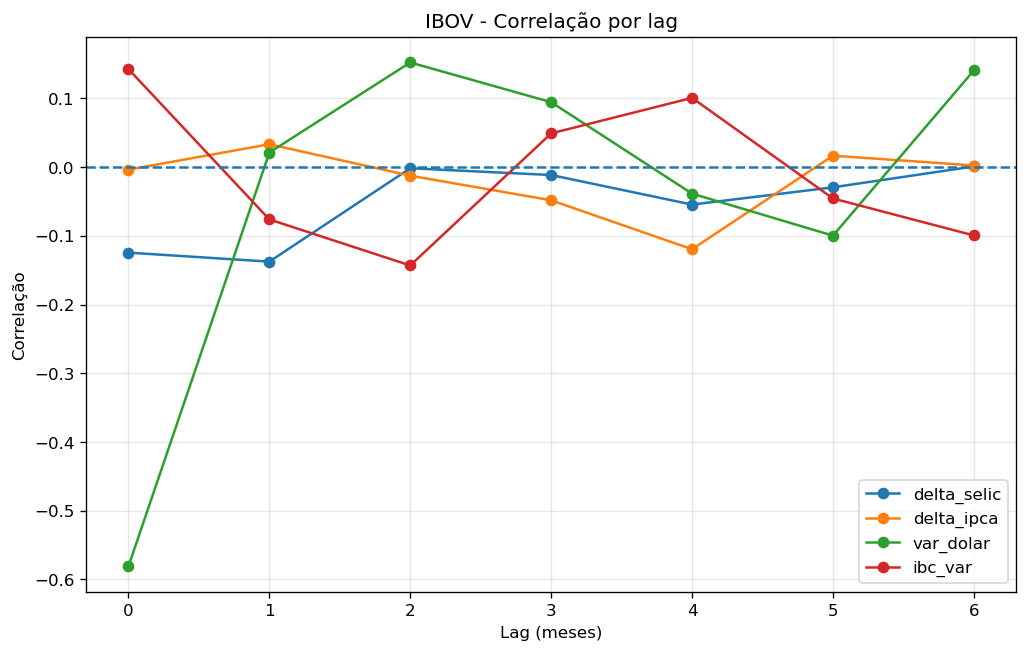

In [35]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for var in macro_cols:
    temp = df_lags_ibov[df_lags_ibov["variavel"] == var]
    ax.plot(temp["lag"], temp["correlacao"], marker="o", label=var)

ax.axhline(0, linestyle="--")
ax.set_title("IBOV - Correlação por lag")
ax.set_xlabel("Lag (meses)")
ax.set_ylabel("Correlação")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "ibov_lags")
plt.show()

In [36]:
# Melhor lag
df_best_lags_ibov = escolher_melhor_lag(df_lags_ibov)

display(df_best_lags_ibov)

salvar_tabela(df_best_lags_ibov, "ibov_melhores_lags")
salvar_parquet(df_best_lags_ibov, "ibov_melhores_lags")

,variavel,melhor_lag,correlacao
0,delta_ipca,4,-0.119534
1,delta_selic,1,-0.137586
2,ibc_var,2,-0.143173
3,var_dolar,0,-0.581120


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_melhores_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_melhores_lags.parquet


## Rolling Correlation

In [37]:
# IBOV - Rolling correlation
df_roll_ibov = df_final_ibov.sort_values("data").copy()

window = 12

for var in macro_cols:
    df_roll_ibov[f"roll_{var}"] = df_roll_ibov["ret_ibov"].rolling(window).corr(df_roll_ibov[var])

cols_roll_ibov = ["data"] + [f"roll_{var}" for var in macro_cols]

salvar_tabela(df_roll_ibov[cols_roll_ibov], "ibov_rolling_correlation")
salvar_parquet(df_roll_ibov[cols_roll_ibov], "ibov_rolling_correlation")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_rolling_correlation.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_rolling_correlation.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\ibov_rolling_correlation.png


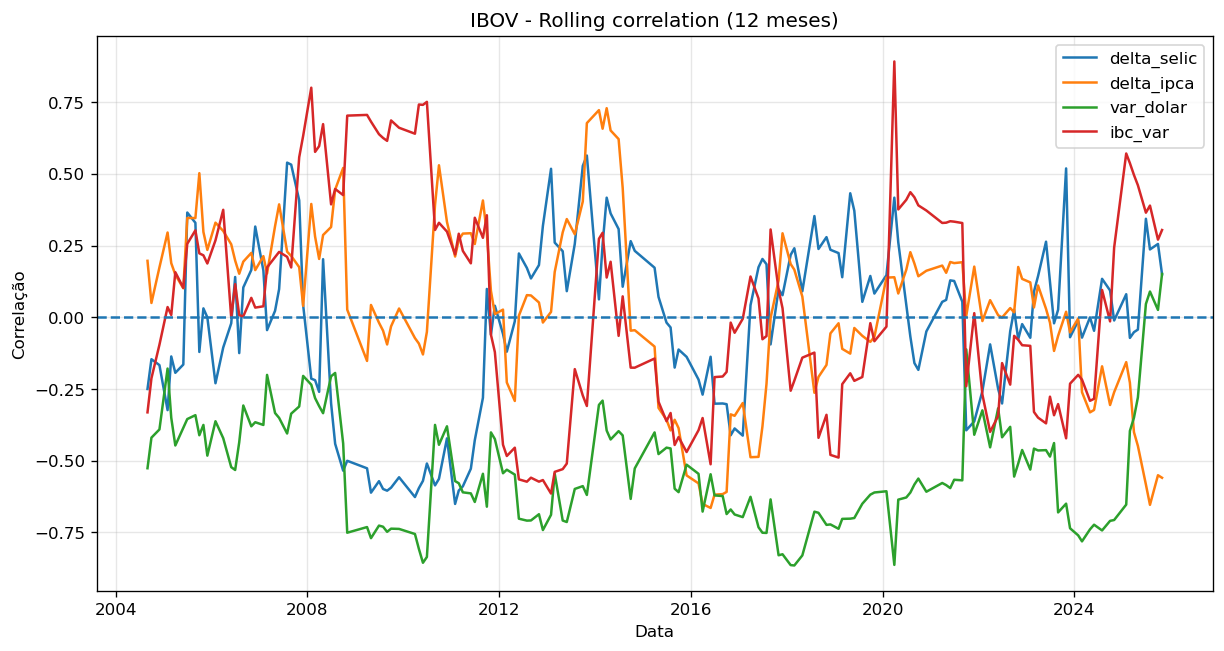

In [38]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for var in macro_cols:
    ax.plot(df_roll_ibov["data"], df_roll_ibov[f"roll_{var}"], label=var)

ax.axhline(0, linestyle="--")
ax.set_title("IBOV - Rolling correlation (12 meses)")
ax.set_xlabel("Data")
ax.set_ylabel("Correlação")
ax.legend()
ax.grid(True, alpha=0.3)

salvar_grafico(fig, "ibov_rolling_correlation")
plt.show()

## Regressão simples

In [39]:
# IBOV - Regressão simples
modelo_ibov_simples, df_coef_ibov_simples, df_modelo_ibov_simples = rodar_regressao(
    df=df_final_ibov,
    y_col="ret_ibov",
    x_cols=macro_cols
)

print(modelo_ibov_simples.summary())
display(df_coef_ibov_simples)

salvar_tabela(df_coef_ibov_simples, "ibov_regressao_simples_coef")
salvar_parquet(df_coef_ibov_simples, "ibov_regressao_simples_coef")
salvar_parquet(df_modelo_ibov_simples, "ibov_regressao_simples_base")

                            OLS Regression Results                            
Dep. Variable:               ret_ibov   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     23.68
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.30e-15
Time:                        16:02:26   Log-Likelihood:                 257.77
No. Observations:                 177   AIC:                            -505.5
Df Residuals:                     172   BIC:                            -489.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0077      0.004      1.754      

,variavel,coef,pvalor
0,const,0.007681,8.115820e-02
1,delta_selic,-0.019364,6.088704e-02
2,delta_ipca,-0.010208,4.687053e-01
3,var_dolar,-1.129833,9.574536e-17
4,ibc_var,-0.306192,4.112571e-01


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_regressao_simples_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_regressao_simples_coef.parquet
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_regressao_simples_base.parquet


## Regressão com lags escolhidos

In [40]:
# IBOV - Regressão com melhores lags
df_ibov_com_lags = aplicar_lags_escolhidos(df_final_ibov.sort_values("data"), df_best_lags_ibov)

x_cols_ibov_lag = [f"{var}_lag" for var in df_best_lags_ibov["variavel"]]

modelo_ibov_lag, df_coef_ibov_lag, df_modelo_ibov_lag = rodar_regressao(
    df=df_ibov_com_lags,
    y_col="ret_ibov",
    x_cols=x_cols_ibov_lag
)

print(modelo_ibov_lag.summary())
display(df_coef_ibov_lag)

salvar_tabela(df_coef_ibov_lag, "ibov_regressao_lags_coef")
salvar_parquet(df_coef_ibov_lag, "ibov_regressao_lags_coef")
salvar_parquet(df_modelo_ibov_lag, "ibov_regressao_lags_base")

                            OLS Regression Results                            
Dep. Variable:               ret_ibov   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     24.36
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.57e-16
Time:                        16:02:26   Log-Likelihood:                 253.96
No. Observations:                 173   AIC:                            -497.9
Df Residuals:                     168   BIC:                            -482.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0076      0.004     

,variavel,coef,pvalor
0,const,0.007588,8.507807e-02
1,delta_ipca_lag,-0.023985,9.015017e-02
2,delta_selic_lag,-0.021060,4.263942e-02
3,ibc_var_lag,-0.465788,1.843568e-01
4,var_dolar_lag,-1.073156,3.020112e-16


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\ibov_regressao_lags_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_regressao_lags_coef.parquet
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\ibov_regressao_lags_base.parquet


# Análise por Subsetor

## Correlação Simples

In [41]:
# Subsetor - Correlação simples por grupo
resultados_corr_subsetor = []

for subsetor in df_final_subsetor["subsetor"].dropna().unique():
    temp = df_final_subsetor[df_final_subsetor["subsetor"] == subsetor].copy()

    if len(temp) < 24:
        continue

    for var in macro_cols:
        corr = temp["ret_subsetor"].corr(temp[var])
        resultados_corr_subsetor.append({
            "subsetor": subsetor,
            "variavel": var,
            "correlacao": corr
        })

df_corr_subsetor = pd.DataFrame(resultados_corr_subsetor)

display(df_corr_subsetor.head())

salvar_tabela(df_corr_subsetor, "subsetor_correlacao_simples")
salvar_parquet(df_corr_subsetor, "subsetor_correlacao_simples")

,subsetor,variavel,correlacao
0,Agropecuária,delta_selic,-0.006109
1,Agropecuária,delta_ipca,0.044425
2,Agropecuária,var_dolar,-0.183882
3,Agropecuária,ibc_var,0.109739
4,Alimentos Processados,delta_selic,-0.123840


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_correlacao_simples.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_correlacao_simples.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\subsetor_correlacao_simples.png


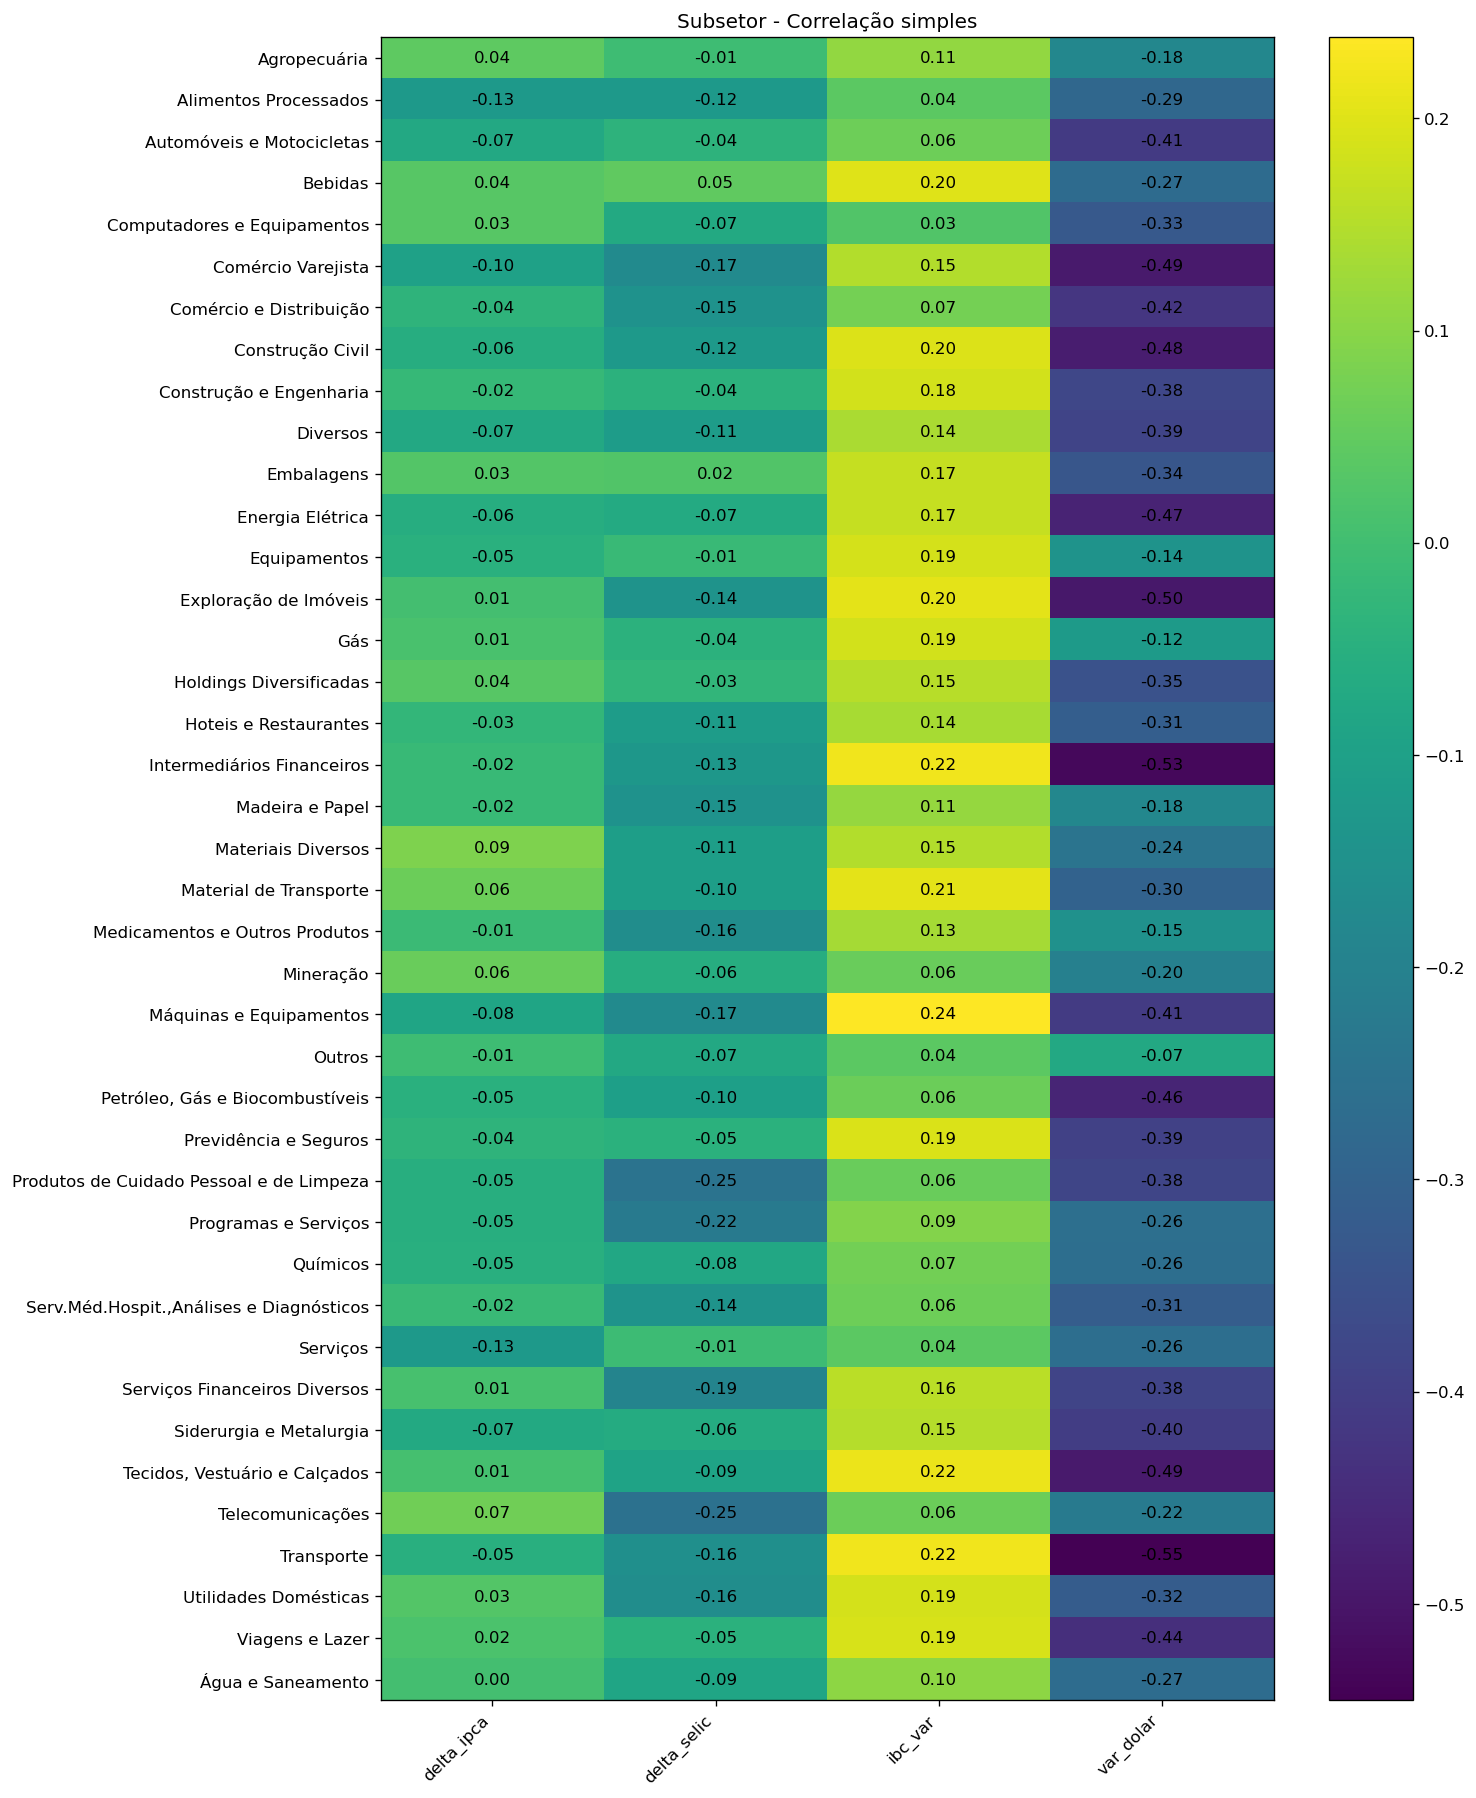

In [42]:
# Heatmap
heat_corr_subsetor = df_corr_subsetor.pivot(index="subsetor", columns="variavel", values="correlacao")

fig, ax = plt.subplots(figsize=(12, 18))
im = ax.imshow(heat_corr_subsetor, aspect="auto")

ax.set_xticks(range(len(heat_corr_subsetor.columns)))
ax.set_xticklabels(heat_corr_subsetor.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_corr_subsetor.index)))
ax.set_yticklabels(heat_corr_subsetor.index)

for i in range(heat_corr_subsetor.shape[0]):
    for j in range(heat_corr_subsetor.shape[1]):
        valor = heat_corr_subsetor.iloc[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.2f}", ha="center", va="center")

ax.set_title("Subsetor - Correlação simples")
fig.colorbar(im, ax=ax)

salvar_grafico(fig, "subsetor_correlacao_simples")
plt.show()

## Lags (Defasagem)

In [43]:
# Subsetor - Lags por grupo
resultados_lags_subsetor = []
resultados_best_lags_subsetor = []

for subsetor in df_final_subsetor["subsetor"].dropna().unique():
    temp = df_final_subsetor[df_final_subsetor["subsetor"] == subsetor].sort_values("data").copy()

    if len(temp) < 24:
        continue

    df_lags_temp = calcular_correlacoes_lag(
        df=temp,
        y_col="ret_subsetor",
        x_cols=macro_cols,
        max_lag=6
    )
    df_lags_temp["subsetor"] = subsetor
    resultados_lags_subsetor.append(df_lags_temp)

    df_best_temp = escolher_melhor_lag(df_lags_temp[["variavel", "lag", "correlacao"]])
    df_best_temp["subsetor"] = subsetor
    resultados_best_lags_subsetor.append(df_best_temp)

df_lags_subsetor = pd.concat(resultados_lags_subsetor, ignore_index=True)
df_best_lags_subsetor = pd.concat(resultados_best_lags_subsetor, ignore_index=True)

display(df_lags_subsetor.head())
display(df_best_lags_subsetor.head())

salvar_tabela(df_lags_subsetor, "subsetor_lags")
salvar_parquet(df_lags_subsetor, "subsetor_lags")

salvar_tabela(df_best_lags_subsetor, "subsetor_melhores_lags")
salvar_parquet(df_best_lags_subsetor, "subsetor_melhores_lags")

,variavel,lag,correlacao,subsetor
0,delta_selic,0,-0.006109,Agropecuária
1,delta_selic,1,-0.039502,Agropecuária
2,delta_selic,2,-0.003940,Agropecuária
3,delta_selic,3,-0.011833,Agropecuária
4,delta_selic,4,-0.098711,Agropecuária


,variavel,melhor_lag,correlacao,subsetor
0,delta_ipca,3,-0.116448,Agropecuária
1,delta_selic,4,-0.098711,Agropecuária
2,ibc_var,4,0.138922,Agropecuária
3,var_dolar,0,-0.183882,Agropecuária
4,delta_ipca,6,0.147945,Alimentos Processados


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_lags.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_melhores_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_melhores_lags.parquet


## Regressão simples por subsetor

In [44]:
# Subsetor - Regressão simples por grupo
resultados_reg_subsetor_simples = []

for subsetor in df_final_subsetor["subsetor"].dropna().unique():
    temp = df_final_subsetor[df_final_subsetor["subsetor"] == subsetor].copy()

    if len(temp) < 24:
        continue

    try:
        model, df_coef, _ = rodar_regressao(
            df=temp,
            y_col="ret_subsetor",
            x_cols=macro_cols
        )

        df_coef["subsetor"] = subsetor
        df_coef["r2"] = model.rsquared
        resultados_reg_subsetor_simples.append(df_coef)

    except Exception:
        continue

df_reg_subsetor_simples = pd.concat(resultados_reg_subsetor_simples, ignore_index=True)

display(df_reg_subsetor_simples.head())

salvar_tabela(df_reg_subsetor_simples, "subsetor_regressao_simples_coef")
salvar_parquet(df_reg_subsetor_simples, "subsetor_regressao_simples_coef")

,variavel,coef,pvalor,subsetor,r2
0,const,0.002511,0.610943,Agropecuária,0.039161
1,delta_selic,-0.003793,0.774153,Agropecuária,0.039161
2,delta_ipca,0.003059,0.829621,Agropecuária,0.039161
3,var_dolar,-0.328677,0.025683,Agropecuária,0.039161
4,ibc_var,0.367479,0.361295,Agropecuária,0.039161


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_regressao_simples_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_regressao_simples_coef.parquet


In [45]:
# Beta Simples
df_beta_subsetor_simples = (
    df_reg_subsetor_simples[df_reg_subsetor_simples["variavel"] != "const"]
    .pivot_table(index="subsetor", columns="variavel", values="coef", aggfunc="first")
    .reset_index()
)

salvar_tabela(df_beta_subsetor_simples, "subsetor_betas_simples")
salvar_parquet(df_beta_subsetor_simples, "subsetor_betas_simples")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_betas_simples.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_betas_simples.parquet


## Regressão com lags por subsetor

In [46]:
# Subsetor - Regressão com melhores lags
resultados_reg_subsetor_lag = []

for subsetor in df_final_subsetor["subsetor"].dropna().unique():
    temp = df_final_subsetor[df_final_subsetor["subsetor"] == subsetor].sort_values("data").copy()

    if len(temp) < 24:
        continue

    best_temp = df_best_lags_subsetor[df_best_lags_subsetor["subsetor"] == subsetor][["variavel", "melhor_lag", "correlacao"]].copy()

    temp_lag = aplicar_lags_escolhidos(temp, best_temp)
    x_cols_lag = [f"{var}_lag" for var in best_temp["variavel"]]

    try:
        model, df_coef, _ = rodar_regressao(
            df=temp_lag,
            y_col="ret_subsetor",
            x_cols=x_cols_lag
        )

        df_coef["subsetor"] = subsetor
        df_coef["r2"] = model.rsquared
        resultados_reg_subsetor_lag.append(df_coef)

    except Exception:
        continue

df_reg_subsetor_lag = pd.concat(resultados_reg_subsetor_lag, ignore_index=True)

display(df_reg_subsetor_lag.head())

salvar_tabela(df_reg_subsetor_lag, "subsetor_regressao_lags_coef")
salvar_parquet(df_reg_subsetor_lag, "subsetor_regressao_lags_coef")

,variavel,coef,pvalor,subsetor,r2
0,const,0.004015,0.410292,Agropecuária,0.076846
1,delta_ipca_lag,-0.023885,0.088029,Agropecuária,0.076846
2,delta_selic_lag,-0.022538,0.083632,Agropecuária,0.076846
3,ibc_var_lag,0.667676,0.084927,Agropecuária,0.076846
4,var_dolar_lag,-0.339236,0.017320,Agropecuária,0.076846


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_regressao_lags_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_regressao_lags_coef.parquet


In [47]:
# Beta melhor Lag
df_beta_subsetor_lag = (
    df_reg_subsetor_lag[df_reg_subsetor_lag["variavel"] != "const"]
    .pivot_table(index="subsetor", columns="variavel", values="coef", aggfunc="first")
    .reset_index()
)

salvar_tabela(df_beta_subsetor_lag, "subsetor_betas_lags")
salvar_parquet(df_beta_subsetor_lag, "subsetor_betas_lags")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_betas_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_betas_lags.parquet


## Clusterização de subsetores

In [48]:
# =============================
# PADRONIZAÇÃO DOS BETAS 
# =============================

# Colunas de betas
beta_cols_subsetor = ["delta_selic_lag", "delta_ipca_lag", "var_dolar_lag", "ibc_var_lag"]

# Copiar dataframe original
df_beta_subsetor_lag_scaled = df_beta_subsetor_lag.copy()

# Inicializar scaler
scaler = StandardScaler()

# Aplicar padronização apenas nas colunas de betas
df_beta_subsetor_lag_scaled[beta_cols_subsetor] = scaler.fit_transform(
    df_beta_subsetor_lag_scaled[beta_cols_subsetor]
)

# -----------------------------
# Verificação 
# -----------------------------
print("Média (deve ser ~0):")
print(df_beta_subsetor_lag_scaled[beta_cols_subsetor].mean())

print("\nDesvio padrão (deve ser ~1):")
print(df_beta_subsetor_lag_scaled[beta_cols_subsetor].std())

# -----------------------------
# Visualizar
# -----------------------------
display(df_beta_subsetor_lag_scaled.head())

Média (deve ser ~0):
variavel
delta_selic_lag    4.440892e-17
delta_ipca_lag    -2.775558e-17
var_dolar_lag     -1.387779e-16
ibc_var_lag       -4.440892e-17
dtype: float64

Desvio padrão (deve ser ~1):
variavel
delta_selic_lag    1.012739
delta_ipca_lag     1.012739
var_dolar_lag      1.012739
ibc_var_lag        1.012739
dtype: float64


variavel,subsetor,delta_ipca_lag,delta_selic_lag,ibc_var_lag,var_dolar_lag
0,Agropecuária,-0.344229,1.023830,0.645161,1.129645
1,Alimentos Processados,0.998875,0.932839,-0.587158,0.732267
2,Automóveis e Motocicletas,-0.496993,0.187433,0.243399,-0.666103
3,Bebidas,-0.242443,2.867667,-1.070716,0.830217
4,Computadores e Equipamentos,-1.643663,-0.587873,-1.345216,-1.027810


In [49]:
# Escolha do K
for k in [3, 4, 5, 6, 7]:
    print(f"\n===== K = {k} =====")

    df_temp, _, centroides = aplicar_kmeans(
        df=df_beta_subsetor_lag_scaled,
        id_col="subsetor",
        beta_cols=beta_cols_subsetor,
        n_clusters=k
    )

    print(df_temp["cluster"].value_counts())
    #display(centroides)


===== K = 3 =====
cluster
1    26
0     8
2     6
Name: count, dtype: int64

===== K = 4 =====
cluster
3    19
1    15
2     5
0     1
Name: count, dtype: int64

===== K = 5 =====
cluster
0    19
1     8
4     7
3     4
2     2
Name: count, dtype: int64

===== K = 6 =====
cluster
3    15
2     9
1     7
5     4
0     4
4     1
Name: count, dtype: int64

===== K = 7 =====
cluster
4    10
1     9
3     9
0     6
2     4
6     1
5     1
Name: count, dtype: int64


In [50]:
# Clusterização de subsetores por exposição macro
beta_cols_subsetor = ["delta_selic_lag", "delta_ipca_lag", "var_dolar_lag", "ibc_var_lag"]

df_cluster_subsetor, centroides_subsetor_scaled, centroides_subsetor_orig = aplicar_kmeans(
    df=df_beta_subsetor_lag_scaled,
    id_col="subsetor",
    beta_cols=beta_cols_subsetor,
    n_clusters=5
)

display(df_cluster_subsetor.head())
display(centroides_subsetor_orig)

variavel,subsetor,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,cluster
0,Agropecuária,1.023830,-0.344229,1.129645,0.645161,4
1,Alimentos Processados,0.932839,0.998875,0.732267,-0.587158,4
2,Automóveis e Motocicletas,0.187433,-0.496993,-0.666103,0.243399,0
3,Bebidas,2.867667,-0.242443,0.830217,-1.070716,2
4,Computadores e Equipamentos,-0.587873,-1.643663,-1.027810,-1.345216,3


,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,cluster
0,-0.086788,-0.484639,-0.211881,0.220598,0
1,-0.026042,1.192596,-0.531462,0.342772,1
2,1.490435,-1.476624,1.924541,-1.912287,2
3,-1.896643,-0.942108,-0.845327,-1.766891,3
4,0.923286,0.912722,1.115666,0.565513,4


In [51]:
# Salvar
salvar_tabela(df_cluster_subsetor, "cluster_subsetores")
salvar_parquet(df_cluster_subsetor, "cluster_subsetores")

salvar_tabela(centroides_subsetor_orig, "cluster_subsetores_centroides")
salvar_parquet(centroides_subsetor_orig, "cluster_subsetores_centroides")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_subsetores.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_subsetores.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_subsetores_centroides.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_subsetores_centroides.parquet


In [52]:
# Heatmap
salvar_tabela(df_cluster_subsetor, "cluster_subsetores")
salvar_parquet(df_cluster_subsetor, "cluster_subsetores")

salvar_tabela(centroides_subsetor_orig, "cluster_subsetores_centroides")
salvar_parquet(centroides_subsetor_orig, "cluster_subsetores_centroides")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_subsetores.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_subsetores.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_subsetores_centroides.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_subsetores_centroides.parquet


In [53]:
# =============================
# RESUMO COMPLETO DOS CLUSTERS
# =============================

# -----------------------------
# 1. Média dos betas por cluster
# -----------------------------
resumo_cluster_subsetor = (
    df_cluster_subsetor
    .groupby("cluster", as_index=False)[beta_cols_subsetor]
    .mean()
)

# -----------------------------
# 2. Dispersão (std)
# -----------------------------
disp_cluster = (
    df_cluster_subsetor
    .groupby("cluster")[beta_cols_subsetor]
    .std()
    .reset_index()
)

disp_cluster = disp_cluster.rename(columns={
    col: f"{col}_std" for col in beta_cols_subsetor
})

# -----------------------------
# 3. Quantidade de subsetores
# -----------------------------
qtd_cluster = (
    df_cluster_subsetor["cluster"]
    .value_counts()
    .reset_index()
)

qtd_cluster.columns = ["cluster", "qtd_subsetores"]

# -----------------------------
# 4. Merge tudo
# -----------------------------
resumo_cluster_subsetor = resumo_cluster_subsetor.merge(disp_cluster, on="cluster")
resumo_cluster_subsetor = resumo_cluster_subsetor.merge(qtd_cluster, on="cluster")

# -----------------------------
# 5. Macro dominante
# -----------------------------
resumo_cluster_subsetor["macro_dominante"] = (
    resumo_cluster_subsetor[beta_cols_subsetor]
    .abs()
    .idxmax(axis=1)
)

# -----------------------------
# 6. Ranking das macros
# -----------------------------
def rank_macros(row):
    return (
        row[beta_cols_subsetor]
        .abs()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

resumo_cluster_subsetor["ranking_macros"] = resumo_cluster_subsetor.apply(rank_macros, axis=1)

# -----------------------------
# 7. Sinais (positivo / negativo)
# -----------------------------
def sinais_cluster(row):
    return {
        col: "positivo" if row[col] > 0 else "negativo"
        for col in beta_cols_subsetor
    }

resumo_cluster_subsetor["sinais"] = resumo_cluster_subsetor.apply(sinais_cluster, axis=1)

# -----------------------------
# 8. Nome econômico do cluster
# -----------------------------
def nomear_cluster(row, threshold=0.5):
    ranking = row[beta_cols_subsetor].abs()

    relevantes = ranking[ranking >= threshold]

    if len(relevantes) == 0:
        return "Baixa sensibilidade"

    relevantes = relevantes.sort_values(ascending=False)

    nomes = {
        "var_dolar_lag": "Dólar",
        "delta_selic_lag": "Juros",
        "ibc_var_lag": "Ciclo Econômico",
        "delta_ipca_lag": "Inflação"
    }

    nomes_legiveis = [nomes[m] for m in relevantes.index]

    return " + ".join(nomes_legiveis)

resumo_cluster_subsetor["nome_cluster"] = resumo_cluster_subsetor.apply(nomear_cluster, axis=1)

# -----------------------------
# 9. Score macro (opcional estratégico)
# -----------------------------
resumo_cluster_subsetor["score_macro"] = (
    - resumo_cluster_subsetor["delta_selic_lag"]
    + resumo_cluster_subsetor["var_dolar_lag"]
    - resumo_cluster_subsetor["delta_ipca_lag"]
    + resumo_cluster_subsetor["ibc_var_lag"]
)

# -----------------------------
# 10. Ordenação final
# -----------------------------
resumo_cluster_subsetor = resumo_cluster_subsetor.sort_values("score_macro", ascending=False)
resumo_cluster_subsetor = resumo_cluster_subsetor.fillna(0)

# -----------------------------
# 11. Exibir
# -----------------------------
display(resumo_cluster_subsetor)

# -----------------------------
# 12. Salvar
# -----------------------------
salvar_tabela(resumo_cluster_subsetor, "resumo_cluster_subsetor")
salvar_parquet(resumo_cluster_subsetor, "resumo_cluster_subsetor")

,cluster,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,delta_selic_lag_std,delta_ipca_lag_std,var_dolar_lag_std,ibc_var_lag_std,qtd_subsetores,macro_dominante,ranking_macros,sinais,nome_cluster,score_macro
0,0,-0.086788,-0.484639,-0.211881,0.220598,0.554911,0.391544,0.603797,0.504582,19,delta_ipca_lag,"[delta_ipca_lag, ibc_var_lag, var_dolar_lag, d...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Baixa sensibilidade,0.580144
3,3,-1.896643,-0.942108,-0.845327,-1.766891,0.879036,0.659614,0.599303,1.120935,4,delta_selic_lag,"[delta_selic_lag, ibc_var_lag, delta_ipca_lag,...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Juros + Ciclo Econômico + Inflação + Dólar,0.226532
2,2,1.490435,-1.476624,1.924541,-1.912287,1.947700,1.745395,1.547608,1.190161,2,var_dolar_lag,"[var_dolar_lag, ibc_var_lag, delta_selic_lag, ...","{'delta_selic_lag': 'positivo', 'delta_ipca_la...",Dólar + Ciclo Econômico + Juros + Inflação,-0.001557
4,4,0.923286,0.912722,1.115666,0.565513,0.607351,0.697907,0.978413,0.654344,7,var_dolar_lag,"[var_dolar_lag, delta_selic_lag, delta_ipca_la...","{'delta_selic_lag': 'positivo', 'delta_ipca_la...",Dólar + Juros + Inflação + Ciclo Econômico,-0.154829
1,1,-0.026042,1.192596,-0.531462,0.342772,0.411424,0.233890,0.551595,0.732675,8,delta_ipca_lag,"[delta_ipca_lag, var_dolar_lag, ibc_var_lag, d...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Inflação + Dólar,-1.355244


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\resumo_cluster_subsetor.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\resumo_cluster_subsetor.parquet


In [54]:
# Quantidade itens por cluster
qtd_cluster_subsetor = (
    df_cluster_subsetor.groupby("cluster", as_index=False)
    .agg(qtd_subsetores=("subsetor", "count"))
)

display(qtd_cluster_subsetor)

salvar_tabela(qtd_cluster_subsetor, "qtd_cluster_subsetor")
salvar_parquet(qtd_cluster_subsetor, "qtd_cluster_subsetor")

,cluster,qtd_subsetores
0,0,19
1,1,8
2,2,2
3,3,4
4,4,7


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\qtd_cluster_subsetor.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\qtd_cluster_subsetor.parquet


## Rankings de subsetores por variável macro

In [55]:
# Rankings de subsetores por variável macro
rankings_subsetor = classificar_sensibilidade(
    df=df_cluster_subsetor,
    id_col="subsetor",
    beta_cols=beta_cols_subsetor
)

for nome, df_rank in rankings_subsetor.items():
    salvar_tabela(df_rank, f"subsetor_{nome}")
    salvar_parquet(df_rank, f"subsetor_{nome}")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_top_positivo_delta_selic_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_top_positivo_delta_selic_lag.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_top_negativo_delta_selic_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_top_negativo_delta_selic_lag.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\subsetor_top_positivo_delta_ipca_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\subsetor_top_positivo_delta_ipca_lag.parquet
Tabela salva em: C

In [56]:
# Mais prejudicados por alta de juros
subsetor_mais_prejudicados_juros = rankings_subsetor["top_negativo_delta_selic_lag"].head(15)

# Mais beneficiados (ou menos prejudicados) por alta de juros
subsetor_mais_beneficiados_juros = rankings_subsetor["top_negativo_delta_selic_lag"].tail(15)

# Mais beneficiados por alta do dólar
subsetor_mais_beneficiados_dolar = rankings_subsetor["top_positivo_var_dolar_lag"].head(15)

# Mais prejudicados por alta do dólar
subsetor_mais_prejudicados_dolar = rankings_subsetor["top_positivo_var_dolar_lag"].tail(15)

# Mais prejudicados por alta do IPCA
subsetor_mais_prejudicados_ipca = rankings_subsetor["top_negativo_delta_ipca_lag"].head(15)

# Mais beneficiados por alta do IPCA
subsetor_mais_beneficiados_ipca = rankings_subsetor["top_negativo_delta_ipca_lag"].tail(15)

# Mais pró-crescimento econômico
subsetor_mais_pro_crescimento = rankings_subsetor["top_positivo_ibc_var_lag"].head(15)

# Menos pró-crescimento / mais defensivos
subsetor_menos_pro_crescimento = rankings_subsetor["top_positivo_ibc_var_lag"].tail(15)

display(subsetor_mais_prejudicados_juros)
display(subsetor_mais_beneficiados_juros)
display(subsetor_mais_beneficiados_dolar)
display(subsetor_mais_prejudicados_dolar)
display(subsetor_mais_prejudicados_ipca)
display(subsetor_mais_beneficiados_ipca)
display(subsetor_mais_pro_crescimento)
display(subsetor_menos_pro_crescimento)

variavel,subsetor,delta_selic_lag
35,Telecomunicações,-2.435646
27,Produtos de Cuidado Pessoal e de Limpeza,-2.377548
19,Materiais Diversos,-2.185506
28,Programas e Serviços,-1.016817
5,Comércio Varejista,-0.958575
7,Construção Civil,-0.788219
29,Químicos,-0.693815
37,Utilidades Domésticas,-0.623095
4,Computadores e Equipamentos,-0.587873
32,Serviços Financeiros Diversos,-0.480194


variavel,subsetor,delta_selic_lag
30,"Serv.Méd.Hospit.,Análises e Diagnósticos",0.347559
6,Comércio e Distribuição,0.380854
38,Viagens e Lazer,0.415634
15,Holdings Diversificadas,0.459420
8,Construção e Engenharia,0.459831
34,"Tecidos, Vestuário e Calçados",0.592345
12,Equipamentos,0.636096
17,Intermediários Financeiros,0.708307
26,Previdência e Seguros,0.759160
10,Embalagens,0.766321


variavel,subsetor,var_dolar_lag
21,Medicamentos e Outros Produtos,3.184740
24,Outros,3.018865
14,Gás,1.319864
0,Agropecuária,1.129645
18,Madeira e Papel,1.116733
3,Bebidas,0.830217
1,Alimentos Processados,0.732267
12,Equipamentos,0.613483
11,Energia Elétrica,0.554958
20,Material de Transporte,0.367510


variavel,subsetor,var_dolar_lag
10,Embalagens,-0.419887
34,"Tecidos, Vestuário e Calçados",-0.501228
2,Automóveis e Motocicletas,-0.666103
8,Construção e Engenharia,-0.687264
38,Viagens e Lazer,-0.689134
31,Serviços,-0.762558
9,Diversos,-0.819909
16,Hoteis e Restaurantes,-0.835327
27,Produtos de Cuidado Pessoal e de Limpeza,-0.925282
4,Computadores e Equipamentos,-1.027810


variavel,subsetor,delta_ipca_lag
24,Outros,-2.710804
4,Computadores e Equipamentos,-1.643663
31,Serviços,-1.454969
19,Materiais Diversos,-1.322269
28,Programas e Serviços,-0.900144
8,Construção e Engenharia,-0.823076
20,Material de Transporte,-0.734913
10,Embalagens,-0.717317
32,Serviços Financeiros Diversos,-0.674716
36,Transporte,-0.645097


variavel,subsetor,delta_ipca_lag
6,Comércio e Distribuição,0.141571
11,Energia Elétrica,0.675297
26,Previdência e Seguros,0.699411
34,"Tecidos, Vestuário e Calçados",0.940425
25,"Petróleo, Gás e Biocombustíveis",0.981300
1,Alimentos Processados,0.998875
22,Mineração,0.999503
33,Siderurgia e Metalurgia,1.003787
21,Medicamentos e Outros Produtos,1.004737
16,Hoteis e Restaurantes,1.316296


variavel,subsetor,ibc_var_lag
22,Mineração,1.453015
12,Equipamentos,1.435725
14,Gás,1.032035
20,Material de Transporte,0.820734
21,Medicamentos e Outros Produtos,0.795469
37,Utilidades Domésticas,0.725885
7,Construção Civil,0.693888
8,Construção e Engenharia,0.686994
23,Máquinas e Equipamentos,0.660318
0,Agropecuária,0.645161


variavel,subsetor,ibc_var_lag
11,Energia Elétrica,0.113304
33,Siderurgia e Metalurgia,0.099471
5,Comércio Varejista,0.051038
28,Programas e Serviços,0.009017
30,"Serv.Méd.Hospit.,Análises e Diagnósticos",-0.540219
1,Alimentos Processados,-0.587158
27,Produtos de Cuidado Pessoal e de Limpeza,-0.680951
6,Comércio e Distribuição,-0.861362
29,Químicos,-0.953535
3,Bebidas,-1.070716


# Análise por Empresa

## Correção Simples

In [57]:
# Empresas - Correlação simples por ticker
resultados_corr_acoes = []

for ticker in df_final_acoes["ticker"].dropna().unique():
    temp = df_final_acoes[df_final_acoes["ticker"] == ticker].copy()

    if len(temp) < 24:
        continue

    for var in macro_cols:
        corr = temp["ret_acao"].corr(temp[var])
        resultados_corr_acoes.append({
            "ticker": ticker,
            "variavel": var,
            "correlacao": corr
        })

df_corr_acoes = pd.DataFrame(resultados_corr_acoes)

display(df_corr_acoes.head())

salvar_tabela(df_corr_acoes, "acoes_correlacao_simples")
salvar_parquet(df_corr_acoes, "acoes_correlacao_simples")

,ticker,variavel,correlacao
0,AALR3,delta_selic,0.183716
1,AALR3,delta_ipca,0.012772
2,AALR3,var_dolar,-0.277608
3,AALR3,ibc_var,0.195519
4,ABCB4,delta_selic,0.049227


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_correlacao_simples.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_correlacao_simples.parquet


## Lags (Defasagem)

In [58]:
# Empresas - Lags por ticker
resultados_lags_acoes = []
resultados_best_lags_acoes = []

for ticker in df_final_acoes["ticker"].dropna().unique():
    temp = df_final_acoes[df_final_acoes["ticker"] == ticker].sort_values("data").copy()

    if len(temp) < 24:
        continue

    df_lags_temp = calcular_correlacoes_lag(
        df=temp,
        y_col="ret_acao",
        x_cols=macro_cols,
        max_lag=6
    )
    df_lags_temp["ticker"] = ticker
    resultados_lags_acoes.append(df_lags_temp)

    df_best_temp = escolher_melhor_lag(df_lags_temp[["variavel", "lag", "correlacao"]])
    df_best_temp["ticker"] = ticker
    resultados_best_lags_acoes.append(df_best_temp)

df_lags_acoes = pd.concat(resultados_lags_acoes, ignore_index=True)
df_best_lags_acoes = pd.concat(resultados_best_lags_acoes, ignore_index=True)

display(df_lags_acoes.head())
display(df_best_lags_acoes.head())

salvar_tabela(df_lags_acoes, "acoes_lags")
salvar_parquet(df_lags_acoes, "acoes_lags")

salvar_tabela(df_best_lags_acoes, "acoes_melhores_lags")
salvar_parquet(df_best_lags_acoes, "acoes_melhores_lags")

,variavel,lag,correlacao,ticker
0,delta_selic,0,0.183716,AALR3
1,delta_selic,1,-0.018482,AALR3
2,delta_selic,2,0.041594,AALR3
3,delta_selic,3,0.023367,AALR3
4,delta_selic,4,0.001925,AALR3


,variavel,melhor_lag,correlacao,ticker
0,delta_ipca,5,-0.055703,AALR3
1,delta_selic,0,0.183716,AALR3
2,ibc_var,0,0.195519,AALR3
3,var_dolar,0,-0.277608,AALR3
4,delta_ipca,6,0.075672,ABCB4


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_lags.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_melhores_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_melhores_lags.parquet


## Regressão simples por empresa

In [59]:
# Empresas - Regressão simples por ticker
resultados_reg_acoes_simples = []

for ticker in df_final_acoes["ticker"].dropna().unique():
    temp = df_final_acoes[df_final_acoes["ticker"] == ticker].copy()

    if len(temp) < 24:
        continue

    try:
        model, df_coef, _ = rodar_regressao(
            df=temp,
            y_col="ret_acao",
            x_cols=macro_cols
        )

        df_coef["ticker"] = ticker
        df_coef["r2"] = model.rsquared
        resultados_reg_acoes_simples.append(df_coef)

    except Exception:
        continue

df_reg_acoes_simples = pd.concat(resultados_reg_acoes_simples, ignore_index=True)

display(df_reg_acoes_simples.head())

salvar_tabela(df_reg_acoes_simples, "acoes_regressao_simples_coef")
salvar_parquet(df_reg_acoes_simples, "acoes_regressao_simples_coef")

,variavel,coef,pvalor,ticker,r2
0,const,-0.017857,0.442159,AALR3,0.10682
1,delta_selic,0.065985,0.249452,AALR3,0.10682
2,delta_ipca,-0.043512,0.496980,AALR3,0.10682
3,var_dolar,-1.416201,0.102269,AALR3,0.10682
4,ibc_var,0.966739,0.534602,AALR3,0.10682


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_regressao_simples_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_regressao_simples_coef.parquet


In [60]:
# Beta Simples
df_beta_acoes_simples = (
    df_reg_acoes_simples[df_reg_acoes_simples["variavel"] != "const"]
    .pivot_table(index="ticker", columns="variavel", values="coef", aggfunc="first")
    .reset_index()
)

salvar_tabela(df_beta_acoes_simples, "acoes_betas_simples")
salvar_parquet(df_beta_acoes_simples, "acoes_betas_simples")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_betas_simples.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_betas_simples.parquet


## Regressão com lags por empresa

In [61]:
# Empresas - Regressão com melhores lags
resultados_reg_acoes_lag = []

for ticker in df_final_acoes["ticker"].dropna().unique():
    temp = df_final_acoes[df_final_acoes["ticker"] == ticker].sort_values("data").copy()

    if len(temp) < 24:
        continue

    best_temp = df_best_lags_acoes[df_best_lags_acoes["ticker"] == ticker][["variavel", "melhor_lag", "correlacao"]].copy()

    temp_lag = aplicar_lags_escolhidos(temp, best_temp)
    x_cols_lag = [f"{var}_lag" for var in best_temp["variavel"]]

    try:
        model, df_coef, _ = rodar_regressao(
            df=temp_lag,
            y_col="ret_acao",
            x_cols=x_cols_lag
        )

        df_coef["ticker"] = ticker
        df_coef["r2"] = model.rsquared
        resultados_reg_acoes_lag.append(df_coef)

    except Exception:
        continue

df_reg_acoes_lag = pd.concat(resultados_reg_acoes_lag, ignore_index=True)

display(df_reg_acoes_lag.head())

salvar_tabela(df_reg_acoes_lag, "acoes_regressao_lags_coef")
salvar_parquet(df_reg_acoes_lag, "acoes_regressao_lags_coef")

,variavel,coef,pvalor,ticker,r2
0,const,-0.023555,0.342262,AALR3,0.119752
1,delta_ipca_lag,-0.023244,0.715104,AALR3,0.119752
2,delta_selic_lag,0.094794,0.140730,AALR3,0.119752
3,ibc_var_lag,0.769306,0.632522,AALR3,0.119752
4,var_dolar_lag,-1.335858,0.134463,AALR3,0.119752


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_regressao_lags_coef.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_regressao_lags_coef.parquet


In [62]:
# Beta melhor Lag
df_beta_acoes_lag = (
    df_reg_acoes_lag[df_reg_acoes_lag["variavel"] != "const"]
    .pivot_table(index="ticker", columns="variavel", values="coef", aggfunc="first")
    .reset_index()
)

salvar_tabela(df_beta_acoes_lag, "acoes_betas_lags")
salvar_parquet(df_beta_acoes_lag, "acoes_betas_lags")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_betas_lags.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_betas_lags.parquet


## Clusterização de ações

In [63]:
# =============================
# PADRONIZAÇÃO DOS BETAS 
# =============================

# Colunas de betas
beta_cols_acoes = ["delta_selic_lag", "delta_ipca_lag", "var_dolar_lag", "ibc_var_lag"]

# Copiar dataframe original
df_beta_acoes_lag_scaled = df_beta_acoes_lag.copy()

# Inicializar scaler
scaler = StandardScaler()

# Aplicar padronização apenas nas colunas de betas
df_beta_acoes_lag_scaled[beta_cols_acoes] = scaler.fit_transform(
    df_beta_acoes_lag_scaled[beta_cols_acoes]
)

# -----------------------------
# Verificação 
# -----------------------------
print("Média (deve ser ~0):")
print(df_beta_acoes_lag_scaled[beta_cols_acoes].mean())

print("\nDesvio padrão (deve ser ~1):")
print(df_beta_acoes_lag_scaled[beta_cols_acoes].std())

# -----------------------------
# Visualizar
# -----------------------------
display(df_beta_acoes_lag_scaled.head())

Média (deve ser ~0):
variavel
delta_selic_lag   -4.078370e-17
delta_ipca_lag     4.531523e-18
var_dolar_lag      8.156741e-17
ibc_var_lag        2.265761e-17
dtype: float64

Desvio padrão (deve ser ~1):
variavel
delta_selic_lag    1.001278
delta_ipca_lag     1.001278
var_dolar_lag      1.001278
ibc_var_lag        1.001278
dtype: float64


variavel,ticker,delta_ipca_lag,delta_selic_lag,ibc_var_lag,var_dolar_lag
0,AALR3,-0.163430,1.653674,0.334139,-0.321091
1,ABCB4,0.114292,0.558483,0.208406,-0.396554
2,ABEV3,0.148506,0.151275,0.307585,0.323779
3,ADHM3,-1.814902,1.406346,0.015037,1.778512
4,AEDU3,1.411263,-1.661162,-1.763126,-0.293472


In [64]:
# Escolha do K
for k in [3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"\n===== K = {k} =====")

    df_temp, _, centroides = aplicar_kmeans(
        df=df_beta_acoes_lag_scaled,
        id_col="ticker",
        beta_cols=beta_cols_subsetor,
        n_clusters=k
    )

    print(df_temp["cluster"].value_counts())
    #display(centroides)


===== K = 3 =====
cluster
1    218
2     96
0     78
Name: count, dtype: int64

===== K = 4 =====
cluster
0    214
2     93
3     75
1     10
Name: count, dtype: int64

===== K = 5 =====
cluster
1    194
3     74
0     63
2     55
4      6
Name: count, dtype: int64

===== K = 6 =====
cluster
3    184
0     69
2     58
4     46
5     28
1      7
Name: count, dtype: int64

===== K = 7 =====
cluster
0    129
1     87
2     68
3     45
5     34
6     25
4      4
Name: count, dtype: int64

===== K = 8 =====
cluster
6    146
0    100
3     45
2     39
5     35
1     20
7      6
4      1
Name: count, dtype: int64

===== K = 9 =====
cluster
5    116
0    106
1     51
8     34
3     32
2     24
7     22
4      6
6      1
Name: count, dtype: int64

===== K = 10 =====
cluster
3    93
1    72
4    69
5    60
0    37
2    26
9    21
6     8
8     5
7     1
Name: count, dtype: int64


In [65]:
# Clusterização de ações por exposição macro
beta_cols_acoes = ["delta_selic_lag", "delta_ipca_lag", "var_dolar_lag", "ibc_var_lag"]

df_cluster_acoes, centroides_acoes_scaled, centroides_acoes_orig = aplicar_kmeans(
    df=df_beta_acoes_lag_scaled,
    id_col="ticker",
    beta_cols=beta_cols_acoes,
    n_clusters=7
)

display(df_cluster_acoes.head())
display(centroides_acoes_orig)

variavel,ticker,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,cluster
0,AALR3,1.653674,-0.163430,-0.321091,0.334139,1
1,ABCB4,0.558483,0.114292,-0.396554,0.208406,0
2,ABEV3,0.151275,0.148506,0.323779,0.307585,0
3,ADHM3,1.406346,-1.814902,1.778512,0.015037,3
4,AEDU3,-1.661162,1.411263,-0.293472,-1.763126,5


,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,cluster
0,0.099397,0.493611,-0.098100,0.338553,0
1,0.906681,-0.190358,-0.199354,-0.303399,1
2,-0.819494,-0.790748,-0.744563,0.062586,2
3,0.274290,-0.325552,1.496041,-0.994910,3
4,-1.946570,-4.434199,1.034301,3.329491,4
5,-1.098387,1.234171,-0.924239,-0.797625,5
6,-0.127580,-0.116756,1.623765,1.481553,6


In [66]:
# Salvar
salvar_tabela(df_cluster_acoes, "cluster_acoes")
salvar_parquet(df_cluster_acoes, "cluster_acoes")

salvar_tabela(centroides_acoes_orig, "cluster_acoes_centroides")
salvar_parquet(centroides_acoes_orig, "cluster_acoes_centroides")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_acoes.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_acoes.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\cluster_acoes_centroides.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\cluster_acoes_centroides.parquet


Gráfico salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\graficos\heatmap_top_acoes_cluster_macro.png


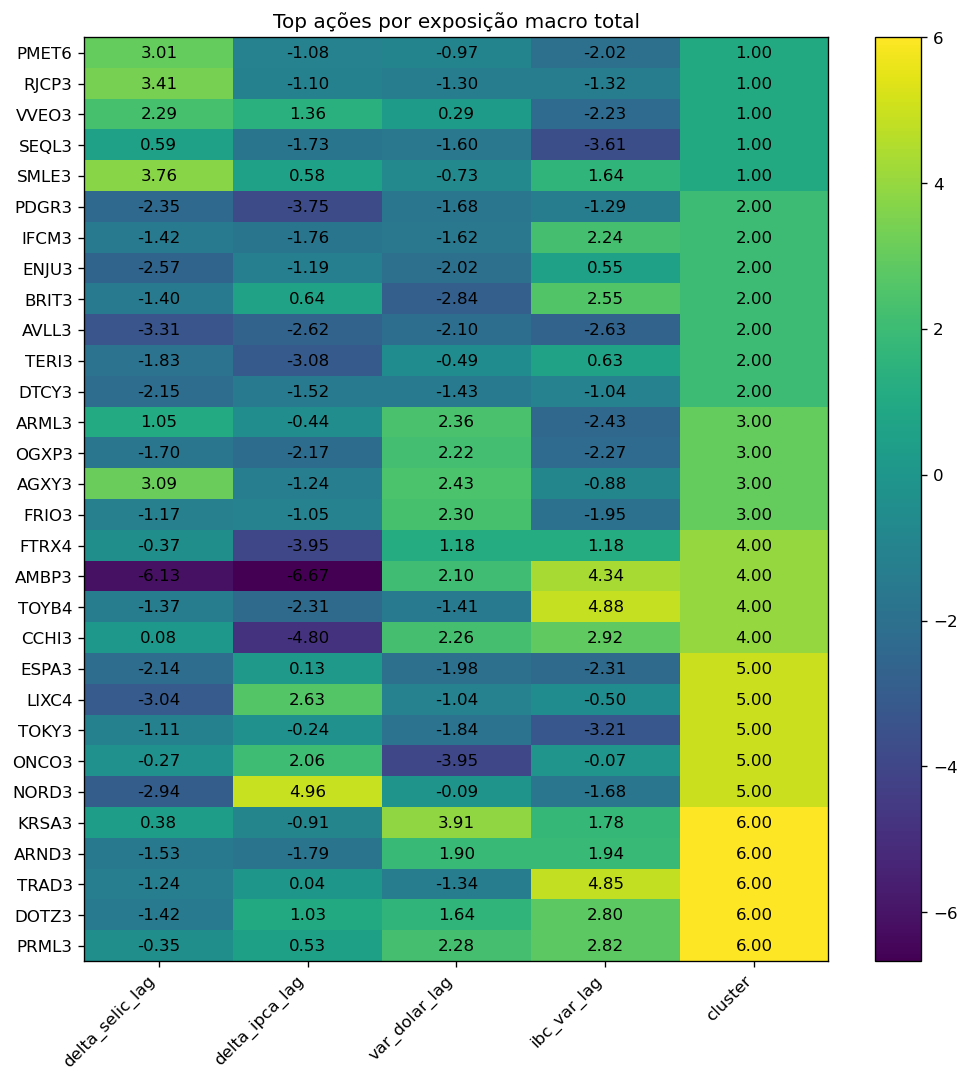

In [67]:
# Heatmap
df_cluster_acoes["score_abs_macro"] = (
    df_cluster_acoes["delta_selic_lag"].abs() +
    df_cluster_acoes["delta_ipca_lag"].abs() +
    df_cluster_acoes["var_dolar_lag"].abs() +
    df_cluster_acoes["ibc_var_lag"].abs()
)

top_heat_acoes = (
    df_cluster_acoes.sort_values("score_abs_macro", ascending=False)
    .head(30)
    .sort_values("cluster")
    .set_index("ticker")[beta_cols_acoes + ["cluster"]]
)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(top_heat_acoes, aspect="auto")

ax.set_xticks(range(len(top_heat_acoes.columns)))
ax.set_xticklabels(top_heat_acoes.columns, rotation=45, ha="right")
ax.set_yticks(range(len(top_heat_acoes.index)))
ax.set_yticklabels(top_heat_acoes.index)

for i in range(top_heat_acoes.shape[0]):
    for j in range(top_heat_acoes.shape[1]):
        valor = top_heat_acoes.iloc[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.2f}", ha="center", va="center")

ax.set_title("Top ações por exposição macro total")

fig.colorbar(im, ax=ax)

salvar_grafico(fig, "heatmap_top_acoes_cluster_macro")
plt.show()

In [68]:
# =============================
# RESUMO COMPLETO DOS CLUSTERS (AÇÕES)
# =============================

# -----------------------------
# 1. Média dos betas por cluster
# -----------------------------
resumo_cluster_acoes = (
    df_cluster_acoes
    .groupby("cluster", as_index=False)[beta_cols_acoes]
    .mean()
)

# -----------------------------
# 2. Dispersão (std)
# -----------------------------
disp_cluster = (
    df_cluster_acoes
    .groupby("cluster")[beta_cols_acoes]
    .std()
    .reset_index()
)

disp_cluster = disp_cluster.rename(columns={
    col: f"{col}_std" for col in beta_cols_acoes
})

# evitar NaN (clusters pequenos)
disp_cluster = disp_cluster.fillna(0)

# -----------------------------
# 3. Quantidade de ações
# -----------------------------
qtd_cluster = (
    df_cluster_acoes["cluster"]
    .value_counts()
    .reset_index()
)

qtd_cluster.columns = ["cluster", "qtd_acoes"]

# -----------------------------
# 4. Merge tudo
# -----------------------------
resumo_cluster_acoes = resumo_cluster_acoes.merge(disp_cluster, on="cluster")
resumo_cluster_acoes = resumo_cluster_acoes.merge(qtd_cluster, on="cluster")

# -----------------------------
# 5. Macro dominante
# -----------------------------
resumo_cluster_acoes["macro_dominante"] = (
    resumo_cluster_acoes[beta_cols_acoes]
    .abs()
    .idxmax(axis=1)
)

# -----------------------------
# 6. Ranking das macros
# -----------------------------
def rank_macros(row):
    return (
        row[beta_cols_acoes]
        .abs()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

resumo_cluster_acoes["ranking_macros"] = resumo_cluster_acoes.apply(rank_macros, axis=1)

# -----------------------------
# 7. Sinais (positivo / negativo)
# -----------------------------
def sinais_cluster(row):
    return {
        col: "positivo" if row[col] > 0 else "negativo"
        for col in beta_cols_acoes
    }

resumo_cluster_acoes["sinais"] = resumo_cluster_acoes.apply(sinais_cluster, axis=1)

# -----------------------------
# 8. Nome econômico do cluster
# -----------------------------
def nomear_cluster(row, threshold=0.5):
    ranking = row[beta_cols_acoes].abs()

    relevantes = ranking[ranking >= threshold]

    if len(relevantes) == 0:
        return "Baixa sensibilidade"

    relevantes = relevantes.sort_values(ascending=False)

    nomes = {
        "var_dolar_lag": "Dólar",
        "delta_selic_lag": "Juros",
        "ibc_var_lag": "Ciclo Econômico",
        "delta_ipca_lag": "Inflação"
    }

    nomes_legiveis = [nomes[m] for m in relevantes.index]

    return " + ".join(nomes_legiveis)

resumo_cluster_acoes["nome_cluster"] = resumo_cluster_acoes.apply(nomear_cluster, axis=1)

# -----------------------------
# 9. Score macro (estratégico)
# -----------------------------
resumo_cluster_acoes["score_macro"] = (
    - resumo_cluster_acoes["delta_selic_lag"]
    + resumo_cluster_acoes["var_dolar_lag"]
    - resumo_cluster_acoes["delta_ipca_lag"]
    + resumo_cluster_acoes["ibc_var_lag"]
)

# -----------------------------
# 10. Ordenação final
# -----------------------------
resumo_cluster_acoes = resumo_cluster_acoes.sort_values("score_macro", ascending=False)

# -----------------------------
# 11. Exibir
# -----------------------------
display(resumo_cluster_acoes)

# -----------------------------
# 12. Salvar
# -----------------------------
salvar_tabela(resumo_cluster_acoes, "resumo_cluster_acoes")
salvar_parquet(resumo_cluster_acoes, "resumo_cluster_acoes")

,cluster,delta_selic_lag,delta_ipca_lag,var_dolar_lag,ibc_var_lag,delta_selic_lag_std,delta_ipca_lag_std,var_dolar_lag_std,ibc_var_lag_std,qtd_acoes,macro_dominante,ranking_macros,sinais,nome_cluster,score_macro
4,4,-1.946570,-4.434199,1.034301,3.329491,2.853221,1.815479,1.695572,1.655803,4,delta_ipca_lag,"[delta_ipca_lag, ibc_var_lag, delta_selic_lag,...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Inflação + Ciclo Econômico + Juros + Dólar,10.744561
6,6,-0.127580,-0.116756,1.623765,1.481553,0.728050,0.710386,0.952183,0.995585,25,var_dolar_lag,"[var_dolar_lag, ibc_var_lag, delta_selic_lag, ...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Dólar + Ciclo Econômico,3.349654
2,2,-0.819494,-0.790748,-0.744563,0.062586,0.678221,0.733753,0.674241,0.812252,68,delta_selic_lag,"[delta_selic_lag, delta_ipca_lag, var_dolar_la...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Juros + Inflação + Dólar,0.928265
3,3,0.274290,-0.325552,1.496041,-0.994910,1.043844,0.832529,0.580573,0.723090,45,var_dolar_lag,"[var_dolar_lag, ibc_var_lag, delta_ipca_lag, d...","{'delta_selic_lag': 'positivo', 'delta_ipca_la...",Dólar + Ciclo Econômico,0.552393
0,0,0.099397,0.493611,-0.098100,0.338553,0.518564,0.440509,0.490532,0.499213,129,delta_ipca_lag,"[delta_ipca_lag, ibc_var_lag, delta_selic_lag,...","{'delta_selic_lag': 'positivo', 'delta_ipca_la...",Baixa sensibilidade,-0.352556
1,1,0.906681,-0.190358,-0.199354,-0.303399,0.716768,0.614474,0.511556,0.762797,87,delta_selic_lag,"[delta_selic_lag, ibc_var_lag, var_dolar_lag, ...","{'delta_selic_lag': 'positivo', 'delta_ipca_la...",Juros,-1.219076
5,5,-1.098387,1.234171,-0.924239,-0.797625,0.760004,1.007129,0.791449,0.823634,34,delta_ipca_lag,"[delta_ipca_lag, delta_selic_lag, var_dolar_la...","{'delta_selic_lag': 'negativo', 'delta_ipca_la...",Inflação + Juros + Dólar + Ciclo Econômico,-1.857648


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\resumo_cluster_acoes.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\resumo_cluster_acoes.parquet


In [69]:
# Quantidade itens por cluster
qtd_cluster_acoes = (
    df_cluster_acoes.groupby("cluster", as_index=False)
    .agg(qtd_acoes=("ticker", "count"))
)

display(qtd_cluster_acoes)

salvar_tabela(qtd_cluster_acoes, "qtd_cluster_acoes")
salvar_parquet(qtd_cluster_acoes, "qtd_cluster_acoes")

,cluster,qtd_acoes
0,0,129
1,1,87
2,2,68
3,3,45
4,4,4
5,5,34
6,6,25


Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\qtd_cluster_acoes.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\qtd_cluster_acoes.parquet


## Rankings de ações por variável macro

In [70]:
# Rankings de ações por variável macro
rankings_acoes = classificar_sensibilidade(
    df=df_cluster_acoes,
    id_col="ticker",
    beta_cols=beta_cols_acoes
)

for nome, df_rank in rankings_acoes.items():
    salvar_tabela(df_rank, f"acoes_{nome}")
    salvar_parquet(df_rank, f"acoes_{nome}")

Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_top_positivo_delta_selic_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_top_positivo_delta_selic_lag.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_top_negativo_delta_selic_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_top_negativo_delta_selic_lag.parquet
Tabela salva em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\tabelas\acoes_top_positivo_delta_ipca_lag.csv
Parquet salvo em: C:\Users\mht-1\OneDrive\Documentos\Projetos\Dados\analise_macro_mercado_brasileiro\resultados\parquets\acoes_top_positivo_delta_ipca_lag.parquet
Tabela salva em: C:\Users\mht-1\OneD

In [71]:
# Mais prejudicadas por alta de juros
acoes_mais_prejudicadas_juros = rankings_acoes["top_negativo_delta_selic_lag"].head(20)

# Mais beneficiadas por alta de juros
acoes_mais_beneficiadas_juros = rankings_acoes["top_negativo_delta_selic_lag"].tail(20)

# Mais beneficiadas por alta do dólar
acoes_mais_beneficiadas_dolar = rankings_acoes["top_positivo_var_dolar_lag"].head(20)

# Mais prejudicadas por alta do dólar
acoes_mais_prejudicadas_dolar = rankings_acoes["top_positivo_var_dolar_lag"].tail(20)

# Mais prejudicadas por alta do IPCA
acoes_mais_prejudicadas_ipca = rankings_acoes["top_negativo_delta_ipca_lag"].head(20)

# Mais beneficiadas por alta do IPCA
acoes_mais_beneficiadas_ipca = rankings_acoes["top_negativo_delta_ipca_lag"].tail(20)

# Mais pró-crescimento
acoes_mais_pro_crescimento = rankings_acoes["top_positivo_ibc_var_lag"].head(20)

# Menos pró-crescimento / mais defensivas
acoes_menos_pro_crescimento = rankings_acoes["top_positivo_ibc_var_lag"].tail(20)

display(acoes_mais_prejudicadas_juros)
display(acoes_mais_beneficiadas_juros)
display(acoes_mais_beneficiadas_dolar)
display(acoes_mais_prejudicadas_dolar)
display(acoes_mais_prejudicadas_ipca)
display(acoes_mais_beneficiadas_ipca)
display(acoes_mais_pro_crescimento)
display(acoes_menos_pro_crescimento)

variavel,ticker,delta_selic_lag
17,AMBP3,-6.127562
29,AVLL3,-3.309906
215,LIXC4,-3.040819
253,NORD3,-2.939586
144,ENJU3,-2.569795
267,PDGR3,-2.352510
112,CTAX3,-2.309603
128,DTCY3,-2.145691
149,ESPA3,-2.136351
259,OIBR3,-1.896411


variavel,ticker,delta_selic_lag
75,BSEV3,1.441541
51,BISA3,1.499795
110,CSRN3,1.596383
341,SULT4,1.622214
52,BLAU3,1.643243
0,AALR3,1.653674
339,SRNA3,1.722263
376,VITT3,1.834964
146,EPAR4,1.914991
381,VSTE3,1.999920


variavel,ticker,var_dolar_lag
206,KRSA3,3.906268
276,PLPL3,2.789303
384,WDCN3,2.562428
80,CBAV3,2.539635
136,ELMD3,2.494407
182,HBTS5,2.478645
92,CLSA3,2.454524
9,AGXY3,2.432684
23,ARML3,2.359567
374,VAMO3,2.330589


variavel,ticker,var_dolar_lag
128,DTCY3,-1.425435
47,BHIA3,-1.547177
378,VIVR3,-1.551710
330,SMFT3,-1.556464
234,MLAS3,-1.594488
322,SEQL3,-1.601229
188,IFCM3,-1.622068
267,PDGR3,-1.683814
31,AZEV4,-1.691894
13,ALPK3,-1.773497


variavel,ticker,delta_ipca_lag
17,AMBP3,-6.674738
82,CCHI3,-4.796920
165,FTRX4,-3.953491
267,PDGR3,-3.753042
353,TERI3,-3.082430
187,IDVL4,-2.641199
29,AVLL3,-2.622107
361,TOYB4,-2.311648
258,OGXP3,-2.171161
19,AMER3,-1.880082


variavel,ticker,delta_ipca_lag
97,COGN3,1.250786
95,CMIN3,1.283499
229,MEAL3,1.307955
383,VVEO3,1.355946
4,AEDU3,1.411263
189,IGBR3,1.442550
183,HETA4,1.485928
386,WEST3,1.491010
192,IMBI4,1.507008
53,BLUT4,1.570387


variavel,ticker,ibc_var_lag
361,TOYB4,4.881555
363,TRAD3,4.848100
17,AMBP3,4.337702
82,CCHI3,2.921751
285,PRML3,2.819241
127,DOTZ3,2.795971
92,CLSA3,2.788470
69,BRIT3,2.554430
188,IFCM3,2.244242
13,ALPK3,1.973560


variavel,ticker,ibc_var_lag
242,MTIG4,-1.690435
150,ESTR4,-1.692118
131,EBTP4,-1.699366
4,AEDU3,-1.763126
66,BRAV3,-1.791420
163,FRIO3,-1.946231
64,BPHA3,-2.011054
278,PMET6,-2.015709
83,CCXC3,-2.059732
234,MLAS3,-2.173705


# Consolidado Final em HTML

In [72]:
# =============================
# CAMINHOS
# =============================
BASE_DIR = Path.cwd()

RESULTADOS_DIR = BASE_DIR / "resultados"
GRAFICOS_DIR = RESULTADOS_DIR / "graficos"
TABELAS_DIR = RESULTADOS_DIR / "tabelas"

# =============================
# FUNÇÕES AUXILIARES
# =============================
def arquivo_existe(pasta, nome, extensao):
    return (pasta / f"{nome}.{extensao}").exists()


def caminho_rel_html(destino_html, arquivo):
    """
    Gera caminho relativo do arquivo em relação ao index.html.
    """
    return arquivo.relative_to(destino_html.parent.parent).as_posix()


def ler_tabela_csv(nome_arquivo, n_linhas=None):
    """
    Lê uma tabela CSV da pasta de resultados.
    Retorna DataFrame ou None caso não exista.
    """
    caminho = TABELAS_DIR / f"{nome_arquivo}.csv"
    if caminho.exists():
        try:
            df = pd.read_csv(caminho)
            return df.head(n_linhas)
        except Exception:
            return None
    return None


def formatar_numero(x):
    """
    Formata números para exibição mais amigável no HTML.
    """
    if pd.isna(x):
        return ""
    if isinstance(x, (int, float)):
        return f"{x:,.4f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return str(x)


def df_para_html(df, titulo=None, classe="data-table"):
    """
    Converte DataFrame em tabela HTML estilizada.
    """
    if df is None or df.empty:
        return ""

    df_fmt = df.copy()
    for col in df_fmt.columns:
        df_fmt[col] = df_fmt[col].apply(formatar_numero)

    titulo_html = f"<h3>{html.escape(titulo)}</h3>" if titulo else ""

    tabela_html = df_fmt.to_html(
        index=False,
        classes=classe,
        border=0,
        escape=False
    )

    return f"""
    <div class="table-block">
        {titulo_html}
        <div class="table-wrapper">
            {tabela_html}
        </div>
    </div>
    """


def imagem_html(nome_arquivo, titulo=None):
    caminho = GRAFICOS_DIR / f"{nome_arquivo}.png"
    if not caminho.exists():
        return ""

    # Caminho relativo a partir da raiz
    caminho_rel = caminho.relative_to(BASE_DIR).as_posix()

    titulo_html = f"<h3>{html.escape(titulo)}</h3>" if titulo else ""

    return f"""
    <div class="chart-card">
        {titulo_html}
        <img src="{caminho_rel}" alt="{html.escape(nome_arquivo)}" class="zoomable-img">
    </div>
    """


def bloco_duplo_imagens(imagens):
    """
    Recebe lista de tuplas: (nome_arquivo, titulo)
    """
    html_imgs = "".join([imagem_html(nome, titulo) for nome, titulo in imagens if arquivo_existe(GRAFICOS_DIR, nome, "png")])
    if not html_imgs:
        return ""
    return f'<div class="grid-2">{html_imgs}</div>'


def bloco_tabelas(tabelas):
    """
    Recebe lista de tuplas: (nome_arquivo, titulo, n_linhas)
    Ordena por data (desc) se existir coluna de data.
    """
    html_tabs = ""

    for nome, titulo, n_linhas in tabelas:
        df = ler_tabela_csv(nome, n_linhas=None)  

        if df is not None:

            # Detectar coluna de data automaticamente
            col_datas = [col for col in df.columns if "data" in col.lower()]

            if col_datas:
                col_data = col_datas[0]

                try:
                    df[col_data] = pd.to_datetime(df[col_data])
                    df = df.sort_values(col_data, ascending=False)
                    df[col_data] = df[col_data].dt.strftime("%Y-%m-%d")
                except:
                    pass 

            # Aplica o corte (se existir)
            if n_linhas is not None:
                df = df.head(n_linhas)

            html_tabs += df_para_html(df, titulo=titulo)

    return html_tabs


def secao_html(titulo, descricao="", conteudo=""):
    """
    Cria uma seção padrão do HTML.
    """
    if not conteudo.strip():
        return ""
    descricao_html = f"<p class='section-desc'>{html.escape(descricao)}</p>" if descricao else ""
    return f"""
    <section class="section">
        <h2>{html.escape(titulo)}</h2>
        {descricao_html}
        {conteudo}
    </section>
    """


# =============================
# CONTEÚDO DAS SEÇÕES
# =============================

# 0. Resumo 
conteudo_resumo = """
<section class="executive-summary">
    <div class="exec-main">
        <h2>Resumo</h2>
        <p>
            Este projeto analisa como variáveis macroeconômicas — juros, inflação, câmbio e atividade econômica —
            se relacionam com o comportamento do mercado acionário brasileiro em três níveis:
            <b>IBOV</b>, <b>subsetores</b> e <b>ações individuais</b>.
        </p>
        <p>
            A análise combina correlações, regressões com defasagens, rankings de sensibilidade e clusterização
            para mapear quais fatores macro aparecem mais associados a diferentes grupos de ativos e como esses
            padrões mudam conforme o nível de agregação.
        </p>

        <div class="highlight-grid">
            <div class="highlight-card">
                <span class="label">Base analisada</span>
                <div class="value">31.596 observações na base final de ações</div>
            </div>
            <div class="highlight-card">
                <span class="label">Nível agregado</span>
                <div class="value">IBOV com maior associação observada a câmbio e juros defasados</div>
            </div>
            <div class="highlight-card">
                <span class="label">Subsetores</span>
                <div class="value">5 clusters para mapear perfis macro estruturais</div>
            </div>
            <div class="highlight-card">
                <span class="label">Ações</span>
                <div class="value">7 clusters para capturar maior heterogeneidade</div>
            </div>
        </div>
    </div>

    <div class="exec-side">
        <h2>Objetivo do estudo</h2>
        <p>
            Construir um <b>mapa de sensibilidade macroeconômica</b> do mercado brasileiro, partindo da hipótese
            de que a leitura do índice agregado pode ser insuficiente para entender o comportamento de setores e ações.
        </p>
        <p>
            O foco não é apenas medir relações estatísticas, mas transformar esses resultados em uma leitura
            exploratória útil para <b>interpretação de cenário e análise de perfis de ativos</b>.
        </p>
    </div>
</section>

<section class="section">
    <h2>Key Takeaways</h2>
    <div class="takeaways">
        <div class="takeaway-card">
            <h3>Câmbio segue central</h3>
            <p>O dólar continua aparecendo como uma das variáveis macro mais associadas à dispersão dos ativos na amostra analisada.</p>
        </div>
        <div class="takeaway-card">
            <h3>Juros importam com defasagem</h3>
            <p>A Selic ganha força especialmente nas análises com lag, em um padrão compatível com uma transmissão mais gradual da política monetária.</p>
        </div>
        <div class="takeaway-card">
            <h3>Heterogeneidade é a regra</h3>
            <p>Subsetores e ações apresentam respostas distintas ao ambiente macro, e a clusterização reforça a heterogeneidade observada dentro da amostra.</p>
        </div>
        <div class="takeaway-card">
            <h3>Atividade não domina sozinha</h3>
            <p>Após padronização, a atividade econômica passou a aparecer de forma mais difusa e combinada com outras variáveis, em vez de dominar isoladamente os agrupamentos.</p>
        </div>
    </div>
</section>
"""

# 1. Visão geral
conteudo_visao_geral = bloco_tabelas([
    ("resumo_bases", "Resumo das bases geradas", None),
])

# 2. Macro
conteudo_macro = bloco_duplo_imagens([
    ("macro_series_nivel", "Séries macroeconômicas em nível"),
    ("macro_series_transformadas", "Transformações das variáveis macroeconômicas"),
]) + bloco_duplo_imagens([
     ("macro_series_base100", "Séries macroeconômicas (Base 100)"),
    ("macro_series_transformadas_base100", "Transformações das variáveis macroeconômicas (Base 100)"),
]) + bloco_tabelas([
    ("df_macro", "Base macroeconômica", None),
])

# 3. IBOV
conteudo_ibov = (
    bloco_duplo_imagens([
        ("ibov_mensal", "IBOV mensal"),
        ("ibov_retorno_mensal", "Retorno logarítmico mensal do IBOV"),
        ("ibov_correlacao_simples", "Correlação simples - IBOV"),
        ("ibov_lags", "Correlação por lag - IBOV"),
        ("ibov_rolling_correlation", "Rolling correlation - IBOV"),
    ])
    +
    bloco_tabelas([
        ("ibov_correlacao_simples", "Tabela de correlação simples - IBOV", None),
        ("ibov_melhores_lags", "Melhores lags - IBOV", None),
        ("ibov_regressao_simples_coef", "Coeficientes da regressão simples - IBOV", None),
        ("ibov_regressao_lags_coef", "Coeficientes da regressão com lags - IBOV", None),
    ])
)

# 4. Subsetores
conteudo_subsetor = (
    bloco_duplo_imagens([
        ("subsetor_correlacao_simples", "Heatmap de correlação simples - subsetores"),
        ("heatmap_subsetores", "Heatmap de sensibilidade macro por subsetor"),
        ("subsetor_heatmap_betas_com_lags", "Heatmap de betas com lags - subsetores"),
        ("heatmap_cluster_subsetores", "Clusterização dos subsetores"),
    ])
    +
    bloco_tabelas([
        ("df_subsetor", "Base agregada de subsetores", None),
        ("subsetor_correlacao_simples", "Correlação simples por subsetor", None),
        ("subsetor_melhores_lags", "Melhores lags por subsetor", None),
        ("subsetor_regressao_simples_coef", "Coeficientes - regressão simples por subsetor", None),
        ("subsetor_regressao_lags_coef", "Coeficientes - regressão com lags por subsetor", None),
        ("cluster_subsetores_centroides", "Centróides dos clusters - subsetores", None),
        ("resumo_cluster_subsetor", "Resumo médio dos clusters - subsetores", None),
    ])
)

# 5. Ações
conteudo_acoes = (
    bloco_duplo_imagens([
        ("heatmap_top_acoes_cluster_macro", "Top ações por exposição macro total"),
    ])
    +
    bloco_tabelas([
        ("acoes_correlacao_simples", "Correlação simples por ação", None),
        ("acoes_melhores_lags", "Melhores lags por ação", None),
        ("acoes_regressao_simples_coef", "Coeficientes - regressão simples por ação", None),
        ("acoes_regressao_lags_coef", "Coeficientes - regressão com lags por ação", None),
        ("cluster_acoes_centroides", "Centróides dos clusters - ações", None),
        ("resumo_cluster_acoes", "Resumo médio dos clusters - ações", None),
    ])
)

# 6. Rankings
conteudo_rankings = bloco_tabelas([
    ("subsetor_top_negativo_delta_selic_lag", "Subsetores mais prejudicados por juros", None),
    ("subsetor_top_negativo_delta_ipca_lag", "Subsetores mais prejudicados por Inflação", None),
    ("subsetor_top_positivo_var_dolar_lag", "Subsetores mais beneficiados pelo dólar", None),
    ("subsetor_top_positivo_ibc_var_lag", "Subsetores mais sensíveis à atividade econômica", None),
    ("acoes_top_negativo_delta_selic_lag", "Ações mais prejudicadas por juros", None),
    ("acoes_top_negativo_delta_ipca_lag", "Ações mais prejudicadas por Inflação", None),
    ("acoes_top_positivo_var_dolar_lag", "Ações mais beneficiadas pelo dólar", None),
    ("acoes_top_positivo_ibc_var_lag", "Ações mais sensíveis à atividade econômica", None),
])

# 7. Clusters
conteudo_clusters = bloco_tabelas([
    ("cluster_subsetores", "Subsetores e seus clusters", None),
    ("qtd_cluster_subsetor", "Quantidade de subsetores por cluster", None),
    ("resumo_cluster_subsetor", "Resumo dos clusters de subsetores com base na sensibilidade às variáveis macroeconômicas", None),
    ("cluster_acoes", "Ações e seus clusters", None),
    ("qtd_cluster_acoes", "Quantidade de ações por cluster", None),
    ("resumo_cluster_acoes", "Resumo dos clusters de ações com base na sensibilidade às variáveis macroeconômicas", None),
])

# 8. Conclusão
conteudo_conclusao = """
<div class="conclusao">
    <h2>Conclusão</h2>

    <p>
        Este projeto sugere que a relação entre variáveis macroeconômicas e o mercado acionário brasileiro
        é relevante, mas está longe de ser uniforme. Ao longo das análises, a leitura do
        <b>IBOV</b> como índice agregado se mostrou apenas uma visão parcial do problema, enquanto a análise por
        <b>subsetores</b> e <b>ações individuais</b> revelou uma heterogeneidade mais rica.
    </p>

    <p>
        No nível agregado, os resultados indicam que o <b>câmbio</b> aparece como uma das variáveis mais associadas
        ao mercado, enquanto a <b>Selic</b>, sobretudo com defasagem, também ganha relevância.
        Isso é compatível com a hipótese de que choques cambiais e mudanças de política monetária se refletem no índice
        por diferentes canais, como custos, valuation e fluxo de capital.
    </p>

    <p>
        Quando a análise avança para subsetores e ações, o ganho de informação é maior. A clusterização
        indicou que o mercado brasileiro pode ser organizado em diferentes perfis de sensibilidade macroeconômica,
        o que reforça a limitação de análises excessivamente agregadas. Em vez de um único comportamento do mercado,
        surgem grupos com exposições distintas a câmbio, juros, inflação e combinações desses fatores.
    </p>

    <p>
        Um resultado importante das etapas mais recentes foi que, após a padronização das exposições macro,
        a <b>atividade econômica</b> deixou de aparecer como fator dominante isolado em muitos agrupamentos.
        Isso sugere que seu impacto está mais distribuído e combinado com outras variáveis, enquanto o câmbio
        continuou aparecendo como um eixo particularmente forte de diferenciação entre ativos na amostra.
    </p>

    <p>
        A escolha final de <b>5 clusters para subsetores</b> e <b>7 clusters para ações</b> buscou equilibrar
        robustez e interpretabilidade. Soluções com poucos clusters geravam grupos excessivamente genéricos,
        enquanto configurações com muitos grupos criavam clusters pequenos demais. Assim, a opção adotada
        permitiu capturar a heterogeneidade dos ativos sem perder legibilidade econômica.
    </p>

    <h3>Principais aprendizados</h3>
    <ul>
        <li><b>Câmbio</b> aparece como uma das variáveis macro mais relevantes para a dispersão dos ativos analisados.</li>
        <li><b>Juros</b> ganham importância quando considerados com defasagem, em linha com um canal mais gradual de transmissão monetária.</li>
        <li><b>Subsetores e ações</b> apresentam respostas distintas ao ambiente macroeconômico.</li>
        <li><b>Atividade econômica</b> parece atuar de forma mais difusa, e não necessariamente como eixo isolado de segmentação.</li>
        <li><b>Clusterização</b> foi útil para transformar exposições macro em perfis interpretáveis de ativos.</li>
    </ul>

    <h3>Conclusão estratégica</h3>
    <p>
        O principal valor deste projeto está em sugerir que abordagens <b>macro-driven</b> podem ganhar mais
        utilidade quando aplicadas a grupos de ativos com perfis semelhantes de sensibilidade, em vez de depender
        apenas da leitura do índice agregado. Isso abre espaço para análises mais sofisticadas de alocação,
        construção de portfólios por cenário e identificação de ganhadores e perdedores em diferentes regimes macroeconômicos.
    </p>
</div>
"""

# =============================
# MONTAGEM DO HTML
# =============================
html_final = f"""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Projeto Macro x IBOV, Subsetores e Ações</title>
    <link rel="stylesheet" href="https://cdn.datatables.net/1.13.8/css/jquery.dataTables.min.css">
    <style>
        body {{
            font-family: Arial, Helvetica, sans-serif;
            background: #f7f8fa;
            color: #1f2937;
            margin: 0;
            padding: 0;
        }}

        .container {{
            width: 92%;
            max-width: 1400px;
            margin: 0 auto;
            padding: 24px 0 48px 0;
        }}

        .hero {{
            background: linear-gradient(135deg, #111827, #1f2937);
            color: white;
            padding: 32px;
            border-radius: 16px;
            margin-bottom: 28px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.15);
        }}

        .hero h1 {{
            margin: 0 0 12px 0;
            font-size: 2rem;
        }}

        .hero p {{
            margin: 6px 0;
            line-height: 1.6;
        }}

        .nav {{
            display: flex;
            flex-wrap: wrap;
            gap: 10px;
            margin-top: 20px;
        }}

        .nav a {{
            text-decoration: none;
            color: white;
            background: rgba(255,255,255,0.12);
            padding: 10px 14px;
            border-radius: 10px;
            font-size: 0.95rem;
        }}

        .section {{
            background: white;
            border-radius: 16px;
            padding: 24px;
            margin-bottom: 24px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
        }}

        .section h2 {{
            margin-top: 0;
            font-size: 1.5rem;
            color: #111827;
        }}

        .section-desc {{
            color: #4b5563;
            margin-bottom: 20px;
            line-height: 1.6;
        }}

        .grid-2 {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(420px, 1fr));
            gap: 20px;
            margin-bottom: 20px;
        }}

        .chart-card {{
            background: #fafafa;
            border: 1px solid #e5e7eb;
            border-radius: 14px;
            padding: 16px;
        }}

        .chart-card h3 {{
            margin-top: 0;
            font-size: 1rem;
        }}

        .chart-card img {{
            width: 100%;
            border-radius: 10px;
            display: block;
        }}

        .table-block {{
            margin-top: 18px;
            margin-bottom: 18px;
        }}

        .table-block h3 {{
            margin-bottom: 10px;
        }}

        .table-wrapper {{
            overflow-x: auto;
            overflow-y: auto;
            max-height: 700px;
            border: 1px solid #e5e7eb;
            border-radius: 12px;
            background: #fff;
        }}

        table.data-table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 0.92rem;
        }}

        table.data-table th,
        table.data-table td {{
            border-bottom: 1px solid #e5e7eb;
            padding: 10px 12px;
            text-align: left;
            white-space: nowrap;
        }}

        table.data-table th {{
            background: #f3f4f6;
        }}

        .footer {{
            text-align: center;
            color: #6b7280;
            font-size: 0.9rem;
            margin-top: 32px;
        }}

        .chart-card img {{
            width: 100%;
            border-radius: 10px;
            display: block;
            cursor: zoom-in;
            transition: transform 0.2s ease;
        }}
        
        .chart-card img:hover {{
            transform: scale(1.01);
        }}
        
        .modal {{
            display: none;
            position: fixed;
            z-index: 9999;
            inset: 0;
            background: rgba(0, 0, 0, 0.88);
            justify-content: center;
            align-items: center;
            padding: 24px;
        }}
        
        .modal.show {{
            display: flex;
        }}
        
        .modal img {{
            max-width: 95%;
            max-height: 92vh;
            border-radius: 12px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.35);
        }}
        
        .modal-close {{
            position: absolute;
            top: 18px;
            right: 24px;
            color: white;
            font-size: 2rem;
            font-weight: bold;
            cursor: pointer;
            line-height: 1;
        }}
        
        .modal-close:hover {{
            opacity: 0.8;
        }}

        .executive-summary {{
            display: grid;
            grid-template-columns: 1.4fr 1fr;
            gap: 20px;
            margin: 0 0 24px 0;
        }}
        
        .exec-main,
        .exec-side {{
            background: white;
            border-radius: 16px;
            padding: 24px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
        }}
        
        .exec-main h2,
        .exec-side h2 {{
            margin-top: 0;
            color: #111827;
        }}
        
        .exec-main p,
        .exec-side p {{
            color: #4b5563;
            line-height: 1.7;
        }}
        
        .highlight-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 16px;
            margin-top: 18px;
        }}
        
        .highlight-card {{
            background: #f9fafb;
            border: 1px solid #e5e7eb;
            border-radius: 14px;
            padding: 16px;
        }}
        
        .highlight-card .label {{
            display: block;
            font-size: 0.85rem;
            color: #6b7280;
            margin-bottom: 8px;
        }}
        
        .highlight-card .value {{
            font-size: 1.05rem;
            font-weight: bold;
            color: #111827;
            line-height: 1.4;
        }}
        
        .takeaways {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
            gap: 16px;
            margin-top: 18px;
        }}
        
        .takeaway-card {{
            background: #111827;
            color: white;
            border-radius: 14px;
            padding: 18px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.10);
        }}
        
        .takeaway-card h3 {{
            margin-top: 0;
            margin-bottom: 10px;
            font-size: 1rem;
        }}
        
        .takeaway-card p {{
            margin: 0;
            line-height: 1.6;
            color: rgba(255,255,255,0.88);
        }}
        
        .conclusao {{
            line-height: 1.8;
        }}
        
        .conclusao h3 {{
            margin-top: 22px;
            color: #111827;
        }}
        
        .conclusao ul {{
            padding-left: 22px;
        }}
        
        .conclusao li {{
            margin-bottom: 8px;
        }}
        
        @media (max-width: 900px) {{
            .executive-summary {{
                grid-template-columns: 1fr;
            }}
        }}
        
    </style>
</head>
<body>
    <div class="container">

        <div class="hero">
            <h1>Impacto de Variáveis Macroeconômicas no IBOV, Subsetores e Ações</h1>
            <p>Mapa de sensibilidade macroeconômica do mercado acionário brasileiro.</p>
            <p>O projeto combina regressões, lags, rankings e clusterização para mapear como juros, inflação, câmbio e atividade econômica se associam a diferentes perfis de ativos no Brasil.</p>
        
            <div class="nav">
                <a href="#visao-geral">Visão Geral</a>
                <a href="#macro">Macro</a>
                <a href="#ibov">IBOV</a>
                <a href="#subsetor">Subsetores</a>
                <a href="#acoes">Ações</a>
                <a href="#rankings">Rankings</a>
                <a href="#clusters">Clusters</a>
                <a href="#conclusao">Conclusão</a>
            </div>
        </div>
        
        {conteudo_resumo}
        
        <div id="visao-geral">
            {secao_html("Visão Geral", "Resumo das bases e estrutura gerada no pipeline.", conteudo_visao_geral)}
        </div>

        <div id="macro">
            {secao_html("Macroeconomia", "Visualização das séries macroeconômicas e suas transformações.", conteudo_macro)}
        </div>

        <div id="ibov">
            {secao_html("IBOV", "Análises do índice agregado: correlação simples, lags, rolling correlation e regressões.", conteudo_ibov)}
        </div>

        <div id="subsetor">
            {secao_html("Subsetores", "Análises agregadas por subsetor, incluindo sensibilidade macro e clusterização.", conteudo_subsetor)}
        </div>

        <div id="acoes">
            {secao_html("Ações", "Análises por ticker, exposição macro e agrupamento por perfil de sensibilidade.", conteudo_acoes)}
        </div>

        <div id="rankings">
            {secao_html("Rankings", "Tabelas com os ativos e subsetores mais e menos sensíveis às variáveis macroeconômicas.", conteudo_rankings)}
        </div>

        <div id="clusters">
            {secao_html("Clusters", "Agrupamentos por perfis de exposição macroeconômica.", conteudo_clusters)}
        </div>

        <div id="conclusao">
            {conteudo_conclusao}
        </div>

        <div class="footer">
            <p>HTML gerado automaticamente a partir dos outputs do projeto.</p>
        </div>
    </div>

    <div id="imgModal" class="modal">
        <span class="modal-close" id="modalClose">&times;</span>
        <img id="modalImg" src="" alt="Imagem ampliada">
    </div>
    
    <script>
        const modal = document.getElementById("imgModal");
        const modalImg = document.getElementById("modalImg");
        const modalClose = document.getElementById("modalClose");
    
        document.querySelectorAll(".zoomable-img").forEach(img => {{
            img.addEventListener("click", () => {{
                modalImg.src = img.src;
                modalImg.alt = img.alt;
                modal.classList.add("show");
            }});
        }});
    
        modalClose.addEventListener("click", () => {{
            modal.classList.remove("show");
            modalImg.src = "";
        }});
    
        modal.addEventListener("click", (e) => {{
            if (e.target === modal) {{
                modal.classList.remove("show");
                modalImg.src = "";
            }}
        }});
    
        document.addEventListener("keydown", (e) => {{
            if (e.key === "Escape") {{
                modal.classList.remove("show");
                modalImg.src = "";
            }}
        }});
    </script>
    <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
    <script src="https://cdn.datatables.net/1.13.8/js/jquery.dataTables.min.js"></script>
    
    <script>
        $(document).ready(function () {{
            $("table.data-table").DataTable({{
                paging: false,
                info: true,
                searching: true,
                ordering: true,
                lengthChange: false,
                order: [],
                language: {{
                    decimal: ",",
                    thousands: ".",
                    zeroRecords: "Nenhum registro encontrado",
                    info: "Mostrando _TOTAL_ registros",
                    infoEmpty: "Mostrando 0 registros",
                    infoFiltered: "(filtrado de _MAX_ registros no total)",
                    search: "Filtrar:",
                    paginate: {{
                        first: "Primeiro",
                        last: "Último",
                        next: "Próximo",
                        previous: "Anterior"
                    }}
                }}
            }});
        }});
    </script>
</body>
</html>
"""


# =============================
# SALVAR HTML
# =============================
HTML_PATH = "index.html"

with open(HTML_PATH, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"HTML salvo em: {HTML_PATH}")

HTML salvo em: index.html


# Conclusão

Este projeto sugere que a relação entre variáveis macroeconômicas e o mercado acionário brasileiro é relevante, mas está longe de ser uniforme. Ao longo das análises, ficou claro que a leitura do **IBOV** como índice agregado fornece apenas uma visão parcial do problema, enquanto a análise por **subsetores** e **ações individuais** revela uma heterogeneidade muito mais rica.

No nível agregado, os resultados indicam que o **câmbio** aparece como uma das variáveis mais associadas ao mercado, enquanto a **Selic**, sobretudo com defasagem, também ganha relevância. Isso é compatível com a hipótese de que choques cambiais e mudanças de política monetária se refletem no índice por diferentes canais, como custos, valuation e fluxo de capital.

Quando a análise avança para subsetores e ações, o ganho de informação é muito maior. A clusterização indicou que o mercado brasileiro pode ser segmentado em diferentes perfis de sensibilidade macroeconômica, o que reforça a limitação de análises excessivamente agregadas. Em vez de um único comportamento do mercado, surgem grupos com exposições distintas a câmbio, juros, inflação e combinações desses fatores.

Um resultado importante das etapas mais recentes foi que, após a padronização das exposições macro, a **atividade econômica** deixou de aparecer como fator dominante isolado em muitos agrupamentos. Isso sugere que seu impacto está mais distribuído e combinado com outras variáveis, enquanto o câmbio continuou aparecendo como um eixo particularmente forte de diferenciação entre ativos na amostra.

A escolha final de **5 clusters para subsetores** e **7 clusters para ações** buscou equilibrar robustez e interpretabilidade. Soluções com poucos clusters geravam grupos excessivamente genéricos, enquanto configurações com muitos grupos criavam clusters pequenos demais. Assim, a opção adotada permitiu capturar a heterogeneidade dos ativos sem perder legibilidade econômica.

Principais aprendizados

- **Câmbio** aparece como uma das variáveis macro mais relevantes para explicar a dispersão dos ativos analisados  
- **Juros** ganham importância quando considerados com defasagem, em linha com um canal mais gradual de transmissão monetária  
- **Subsetores e ações** apresentam respostas distintas ao ambiente macroeconômico  
- **Atividade econômica** parece atuar de forma mais difusa, e não necessariamente como eixo isolado de segmentação  
- **Clusterização** foi útil para transformar exposições macro em perfis interpretáveis de ativos  

Conclusão estratégica

O principal valor deste projeto está em sugerir que abordagens **macro-driven** podem ganhar mais utilidade quando aplicadas a grupos de ativos com perfis semelhantes de sensibilidade, em vez de depender apenas da leitura do índice agregado. Isso abre espaço para análises mais sofisticadas de alocação, construção de portfólios por cenário e identificação de ganhadores e perdedores em diferentes regimes macroeconômicos.